# Med Center Shuttle Peak Hours Analysis and Recommendations

This notebook will analyze the APC ridership data to assist in optimizing bus deployment across the med center express shuttle. The analysis will use BusState files from March 2, 2026 - April 17, 2026, this represents 7 weeks worth of data collected M-F.

### Directions

**Inbound:** Carmack 2, 3, 5A and 5B -> University Hospital, Doan Hall

**Outbound:** University Hospital, Doan Hall -> Carmack 2, 3, 5A and 5B

### Key Variables Used
- STOP_ID:      The ID of the stop (401, 403, 404, 94, 95, 401, 37)
- ARRIVAL:      Arrival time of the bus at the current stop
- DEPARTURE:    Departure time of the bus at the current stop
- BOARDINGS:    Number of boardings detected by APC at the current stop 
- ALIGHTINGS:   Number of alightings detected by APC at the current stop
- HOUR:         Hour of event
- MINUTE:       Minute of event
- DATE:         Date of event

In [2]:
# %pip install statsmodels

import sys
import os
import pandas as pd
import numpy as np
import importlib
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from statsmodels.graphics.mosaicplot import mosaic

# Global config for analysis and viz

# boilerplate for all viz
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F8F6',
    'axes.grid':        True,
    'grid.color':       '#E0DED8',
    'grid.linewidth':   0.6,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.spines.left': False,
    'axes.spines.bottom': False,
    'font.family':      'sans-serif',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.labelsize':   11,
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
})

# seaborn styles set
sns.set_style("whitegrid", {
    'axes.facecolor': '#F8F8F6',
    'grid.color':       '#E0DED8',
    'grid.linewidth':   0.6,
})

# stop id and names
STOP_NAMES = {
    37: 'Doan Hall',
    94: 'Carmack 5A',
    95: 'Carmack 5B',
    401: 'University Hospital',
    403: 'Carmack 2',
    404: 'Carmack 3'
}

# bus max capacity
BUS_CAPACITY = 65 # based on previous analysis, 65 is generally considered the max capacity for a cabs bus
BUS_CAPACITY_COMFORT = 50 # this is a guess of what a 'comfortable' capacity may be. Will cross reference with number of seats, etc in future
CARMACK_5_BEGINS = 7 # busses stop at carmack 5 starting after 7am according to run books


---

## Loading and Validation of Data

Input month and year of the targeted month.

- **MONTH:** 3 character abbreviation (ex. MAR)
- **YEAR:** 4 digit number (ex. 2026)

### Note: Raw busstate files will need to be processed in `busstate_processing_pipeline.ipynb` first before running

In [3]:
# go up one level from notebook folder
sys.path.append(os.path.abspath(".."))

from modules import med_center_dashboard as mcd
importlib.reload(mcd)

data_dir = "K:/AP/TTM/Data/WMC_Dashboard/busstate_cleaned"

# month and date dict
MONTH = 'APR'
YEAR = 2026

# set dir to save cleaned files to 
# repo_dir = "K:/AP/TTM/Data/WMC_Dashboard/analysis_data/peak_hours_cleaned"

df = mcd.process_mc_busstate(year=YEAR, month=MONTH, current_dir=data_dir)

In [4]:
# Cut down df to necessary columns
mc_df = df[['DATE', 'STOP_ID', 'BOARDINGS', 'ALIGHTINGS', 'RUN_ID', 'ARRIVAL', 'DEPARTURE', 'DWELL', 'HOUR', 'MINUTE']].copy()
mc_df.columns = mc_df.columns.str.lower()

# map for inbound vs outbound stops
DIRECTION_MAP = {
    37: 'Outbound',
    94: 'Inbound',
    95: 'Inbound',
    401: 'Outbound',
    403: 'Inbound',
    404: 'Inbound'
}

# Parse time-related columns
mc_df['arrival'] = pd.to_datetime(mc_df['arrival'])
mc_df['departure'] = pd.to_datetime(mc_df['departure'])
mc_df['dwell'] = pd.to_timedelta(mc_df['dwell'], unit='s')
mc_df['time'] = pd.to_datetime(mc_df['date'].astype(str) + ' ' + mc_df['arrival'].dt.time.astype(str))

mc_df.sort_values(by='time', inplace=True)

# Normalize numeric dtypes
mc_df['stop_id'] = mc_df['stop_id'].astype(int)
mc_df['boardings'] = mc_df['boardings'].astype(int)
mc_df['alightings'] = mc_df['alightings'].astype(int)
mc_df['run_id'] = mc_df['run_id'].astype(int)

# Add convenience columns
mc_df['stop_name'] = mc_df['stop_id'].map(STOP_NAMES)
mc_df['weekday'] = mc_df['date'].dt.day_name()  # in case weekday-related patterns surface
mc_df['dwell_sec'] = mc_df['dwell'].dt.total_seconds()
mc_df['weekday_num'] = mc_df['date'].dt.weekday  # Monday=0, Sunday=6
mc_df['direction'] = mc_df['stop_id'].map(DIRECTION_MAP)

# print total boardings before dropping sat/sun for month sanity check
# total_boardings = mc_df['boardings'].sum()
# print(f'{total_boardings} total boardings')

# Remove weekend rows currently out of scope
mc_df = mc_df[mc_df['weekday'] != 'Saturday']
mc_df = mc_df[mc_df['weekday'] != 'Sunday']

In [5]:
# Shape and data check
print(f'Records : {len(mc_df)}')
print(f'Date range : {mc_df["date"].min().date()}  - {mc_df["date"].max().date()}')
print(f'Unique dates : {mc_df["date"].dt.date.nunique()}')
print(mc_df.dtypes)
mc_df.head(3)

Records : 37861
Date range : 2026-04-01  - 2026-04-30
Unique dates : 22
date            datetime64[us]
stop_id                  int64
boardings                int64
alightings               int64
run_id                   int64
arrival         datetime64[us]
departure       datetime64[us]
dwell          timedelta64[us]
hour                     int32
minute                   int32
time            datetime64[us]
stop_name                  str
weekday                    str
dwell_sec              float64
weekday_num              int32
direction                  str
dtype: object


,date,stop_id,boardings,alightings,run_id,arrival,departure,dwell,hour,minute,time,stop_name,weekday,dwell_sec,weekday_num,direction
24476,2026-04-01,94,0,1,1501,1900-01-01 00:00:31,1900-01-01 00:00:56,0 days 00:00:25,0,0,2026-04-01 00:00:31,Carmack 5A,Wednesday,25.0,2,Inbound
10598,2026-04-01,403,0,0,1502,1900-01-01 00:01:44,1900-01-01 00:01:53,0 days 00:00:09,0,1,2026-04-01 00:01:44,Carmack 2,Wednesday,9.0,2,Inbound
7712,2026-04-01,401,2,14,1503,1900-01-01 00:02:29,1900-01-01 00:03:11,0 days 00:00:42,0,2,2026-04-01 00:02:29,University Hospital,Wednesday,42.0,2,Outbound


In [6]:
# Missing data check
missing = mc_df.isnull().sum()
missing

date           0
stop_id        0
boardings      0
alightings     0
run_id         0
arrival        0
departure      0
dwell          0
hour           0
minute         0
time           0
stop_name      0
weekday        0
dwell_sec      0
weekday_num    0
direction      0
dtype: int64

In [7]:
# Data ranges and distributions check
mc_df.describe()

,date,stop_id,boardings,alightings,run_id,arrival,departure,dwell,hour,minute,time,dwell_sec,weekday_num
count,37861,37861.000000,37861.000000,37861.000000,37861.000000,37861,37861,37861,37861.000000,37861.000000,37861,37861.000000,37861.000000
mean,2026-04-15 17:44:47.757851,247.188215,3.573809,3.516547,1504.286178,1900-01-01 13:23:32.694805,1900-01-01 13:24:41.823249,0 days 00:01:09.128443,12.897203,29.224136,2026-04-16 07:08:20.452655,69.128444,2.053512
min,2026-04-01 00:00:00,37.000000,0.000000,0.000000,1501.000000,1900-01-01 00:00:01,1900-01-01 00:00:08,0 days 00:00:00,0.000000,0.000000,2026-04-01 00:00:31,0.000000,0.000000
25%,2026-04-08 00:00:00,94.000000,0.000000,0.000000,1502.000000,1900-01-01 07:39:12,1900-01-01 07:40:07,0 days 00:00:35,7.000000,14.000000,2026-04-08 16:06:30,35.000000,1.000000
50%,2026-04-16 00:00:00,401.000000,1.000000,1.000000,1504.000000,1900-01-01 14:22:12,1900-01-01 14:23:12,0 days 00:00:52,14.000000,29.000000,2026-04-16 05:53:03,52.000000,2.000000
75%,2026-04-23 00:00:00,403.000000,5.000000,5.000000,1506.000000,1900-01-01 18:31:18,1900-01-01 18:32:31,0 days 00:01:25,18.000000,44.000000,2026-04-23 14:41:49,85.000000,3.000000
max,2026-04-30 00:00:00,404.000000,53.000000,47.000000,1514.000000,1900-01-01 23:59:58,1900-01-01 23:59:58,0 days 00:16:50,23.000000,59.000000,2026-04-30 23:59:39,1010.000000,4.000000
std,NaN,165.666278,5.624932,5.362966,2.852873,NaN,NaN,0 days 00:00:53.643963,6.105837,17.518103,NaN,53.643963,1.360366



---
## Analysis and Visualization of the Data
**Notes:**
- mc_df denotes the dataframe with the busstate data for the sample of 3/1/2026 - 4/14/2026
- The sample timeframe of 3/1/2026 - 4/14/2026 was chosen due to the new hospital tower opening in late February 2026
    - This should give the best possible view of staffing and demand changes to the shuttle


---

## Key Metrics Summary

In [8]:
# Aggregate to hourly totals
hourly_mc_df = (
    mc_df.groupby('hour')
    .agg(
        total_boardings=('boardings', 'sum'),
        total_alightings=('alightings', 'sum'),
        avg_dwell_sec=('dwell_sec', 'mean')
    )
    .reset_index()
)

# Sanity check of total boardings and alightings
total_boardings = hourly_mc_df['total_boardings'].sum()
total_alightings = hourly_mc_df['total_alightings'].sum()

# Total number of each within 5000
e = total_boardings - total_alightings
print(f'Total boardings: {total_boardings}')
print(f'Total alightings: {total_alightings}')
print(f'Difference: {e}')
# The total boardings and alightings should theoretically be the same
# The difference is likely due to APC data collection error
# Given the large sample size, this small difference should not significantly impact the overall analysis

Total boardings: 135308
Total alightings: 133140
Difference: 2168


In [9]:
# summary stats
peak_hour   = hourly_mc_df.loc[hourly_mc_df['total_boardings'].idxmax(), 'hour']
peak_vol    = hourly_mc_df['total_boardings'].max()
avg_dwell   = hourly_mc_df['avg_dwell_sec'].mean()

peak_hour, peak_vol, avg_dwell

(np.int32(6), np.int64(17448), np.float64(67.763468602537))


---

### Visualization 1: Total Hourly Boarding Volume

Broad overview to get an idea of the total demand and throughput of the shuttle through an hourly breakdown.

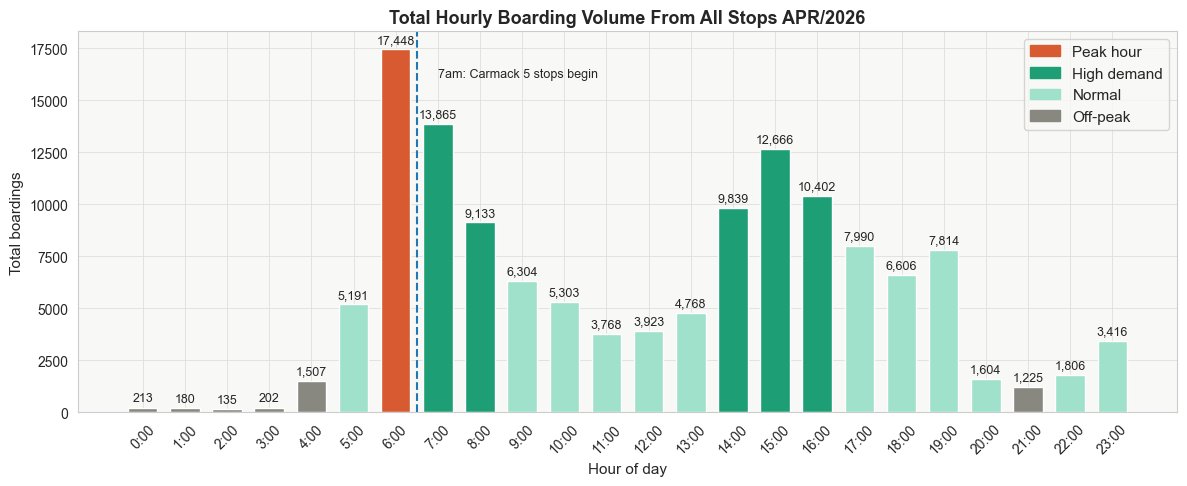

Lower Threshold (25th percentile): 1579.75
Upper Threshold (75th percentile): 8275.75


In [10]:
# Starting at 7am the busses will stop at the carmack stops too.

# define the quartiles for boardings for color coding
q1 = hourly_mc_df['total_boardings'].quantile(0.25)
q3 = hourly_mc_df['total_boardings'].quantile(0.75)

# plot the hourly boardings accross all stops to get a sense of overall traffic

TEAL   = '#1D9E75'       # high demand
GRAY   = '#888780'       # off-peak
CORAL  = '#D85A30'       # peak hour
LIGHT_TEAL   = '#9FE1CB' # 'normal' demand

fig, ax = plt.subplots(figsize=(12, 5))

# define colors for each demand level
def get_color(hour, boardings):
    if hour == peak_hour:
        return CORAL # peak capacity hour
    elif (boardings ) >= q3: # high demand
        return TEAL
    elif boardings <= q1: # low demand
        return GRAY
    return LIGHT_TEAL # normal

colors = [
    get_color(h, b)
    for h, b in zip(hourly_mc_df['hour'], hourly_mc_df['total_boardings'])
]

# x = hour, y =total boardings, color coded by demand
bars = ax.bar(
    hourly_mc_df['hour'],
    hourly_mc_df['total_boardings'],
    color=colors,
    width=0.7
)

# add the value to each bar
max_val = hourly_mc_df['total_boardings'].max()
for bar in bars:
    height = bar.get_height()
    if height > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + max_val * 0.01,
            f'{int(height):,}',
            ha='center',
            va='bottom',
            fontsize=9
        )

# mark time when carmack 5 stops start
ax.axvline(CARMACK_5_BEGINS - 0.5, linestyle='--', linewidth=1.5)

ax.text(
    CARMACK_5_BEGINS,
    max_val * 0.95,
    '7am: Carmack 5 stops begin',
    fontsize=9,
    va='top'
)

# legend
ax.legend(handles=[
    mpatches.Patch(color=CORAL, label='Peak hour'),
    mpatches.Patch(color=TEAL, label='High demand'),
    mpatches.Patch(color=LIGHT_TEAL, label='Normal'),
    mpatches.Patch(color=GRAY, label='Off-peak')
])

# format axes
ax.set(
    xticks=hourly_mc_df['hour'],
    xticklabels=[f'{h}:00' for h in hourly_mc_df['hour']],
    xlabel='Hour of day',
    ylabel='Total boardings',
    title=f'Total Hourly Boarding Volume From All Stops {MONTH}/{YEAR}'
)
# make easier to see
plt.xticks(rotation=45)
plt.tight_layout()
# plt.savefig(f'1_total_hourly_boardings_all_stops_{MONTH}_{YEAR}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Lower Threshold (25th percentile): {q1}')
print(f'Upper Threshold (75th percentile): {q3}')

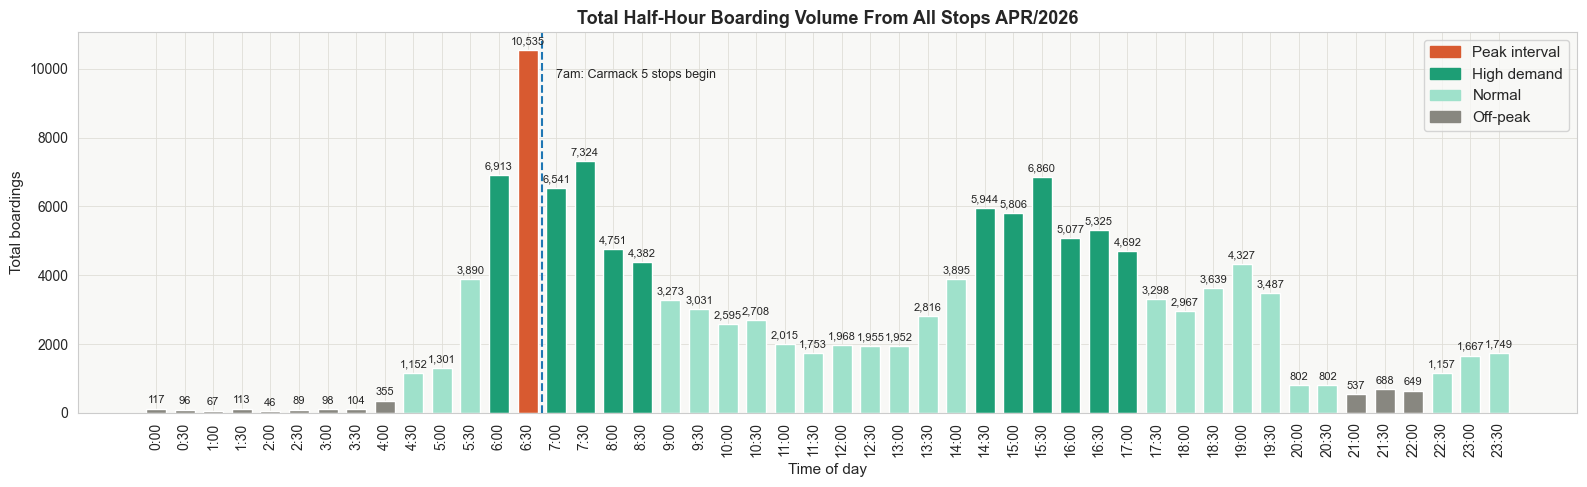

Lower Threshold (25th percentile): 773.5
Upper Threshold (75th percentile): 4340.75


In [11]:
# Same plot but with half-hour intervals
# Starting at 7am the busses will stop at the carmack stops too.

half_hourly_mc_df = mc_df.copy()
half_hourly_mc_df['half_hour'] = (half_hourly_mc_df['minute'] // 30) * 30
half_hourly_mc_df['time_bin'] = half_hourly_mc_df['hour'] + (half_hourly_mc_df['half_hour'] / 60)

half_hourly_mc_df = (
    half_hourly_mc_df.groupby(['time_bin'], as_index=False)
    .agg(
        total_boardings=('boardings', 'sum'),
        total_alightings=('alightings', 'sum'),
        avg_dwell_sec=('dwell_sec', 'mean')
    )
    .sort_values('time_bin')
)

peak_time_bin = half_hourly_mc_df.loc[half_hourly_mc_df['total_boardings'].idxmax(), 'time_bin']

# define the quartiles for boardings for color coding
q1 = half_hourly_mc_df['total_boardings'].quantile(0.25)
q3 = half_hourly_mc_df['total_boardings'].quantile(0.75)

# plot the half-hourly boardings accross all stops to get a sense of overall traffic
TEAL = '#1D9E75'        # high demand
GRAY = '#888780'        # off-peak
CORAL = '#D85A30'       # peak interval
LIGHT_TEAL = '#9FE1CB'  # 'normal' demand

fig, ax = plt.subplots(figsize=(16, 5))

# define colors for each demand level
def get_color(time_bin, boardings):
    if time_bin == peak_time_bin:
        return CORAL  # peak capacity interval
    elif boardings >= q3:  # high demand
        return TEAL
    elif boardings <= q1:  # low demand
        return GRAY
    return LIGHT_TEAL  # normal

colors = [
    get_color(time_bin, boardings)
    for time_bin, boardings in zip(half_hourly_mc_df['time_bin'], half_hourly_mc_df['total_boardings'])
]

# x = half-hour bin, y = total boardings, color coded by demand
bars = ax.bar(
    half_hourly_mc_df['time_bin'],
    half_hourly_mc_df['total_boardings'],
    color=colors,
    width=0.35
)

# add the value to each bar
max_val = half_hourly_mc_df['total_boardings'].max()
for bar in bars:
    height = bar.get_height()
    if height > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + max_val * 0.01,
            f'{int(height):,}',
            ha='center',
            va='bottom',
            fontsize=8
        )

# mark time when Carmack 5 stops start
ax.axvline(CARMACK_5_BEGINS - 0.25, linestyle='--', linewidth=1.5)
ax.text(
    CARMACK_5_BEGINS,
    max_val * 0.95,
    '7am: Carmack 5 stops begin',
    fontsize=9,
    va='top'
)

# legend
ax.legend(handles=[
    mpatches.Patch(color=CORAL, label='Peak interval'),
    mpatches.Patch(color=TEAL, label='High demand'),
    mpatches.Patch(color=LIGHT_TEAL, label='Normal'),
    mpatches.Patch(color=GRAY, label='Off-peak')
])

# format axes
ax.set(
    xticks=half_hourly_mc_df['time_bin'],
    xticklabels=[f"{int(t)}:{'30' if (t % 1) == 0.5 else '00'}" for t in half_hourly_mc_df['time_bin']],
    xlabel='Time of day',
    ylabel='Total boardings',
    title=f'Total Half-Hour Boarding Volume From All Stops {MONTH}/{YEAR}'
)
plt.xticks(rotation=90)
plt.tight_layout()
# plt.savefig(f'1b_total_half_hour_boardings_all_stops_{MONTH}_{YEAR}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Lower Threshold (25th percentile): {q1}')
print(f'Upper Threshold (75th percentile): {q3}')

In [12]:
# calculate the total total sum of boardings
total_boardings = mc_df['boardings'].sum()
weekday_count = mc_df['date'].dt.date.nunique()
print(f'{total_boardings} total boardings across {weekday_count} weekdays in {MONTH}/{YEAR}')

# The reason this is lower than the total boarding calculated prior is since we have dropped Saturday/Sunday data - likely overflowed from a late Friday night or early Monday morning
# This amounts to 79 total boardings - considered negligible

135308 total boardings across 22 weekdays in APR/2026


### **Interpretation:**

Peak hourly boarding volume is within the 0600 hour. This makes sense with a moderately standardized 0700 shift start. This peak is followed by 2 more hours of high demand until leveling out at 0900. Afternoon peak is less concentrated and begins in the 1400 hour and does not reach 'off peak' until 2100. 


---

### Visualization 2: Day of Week Patterns

Determine if there is a difference in demand for specific days of the week

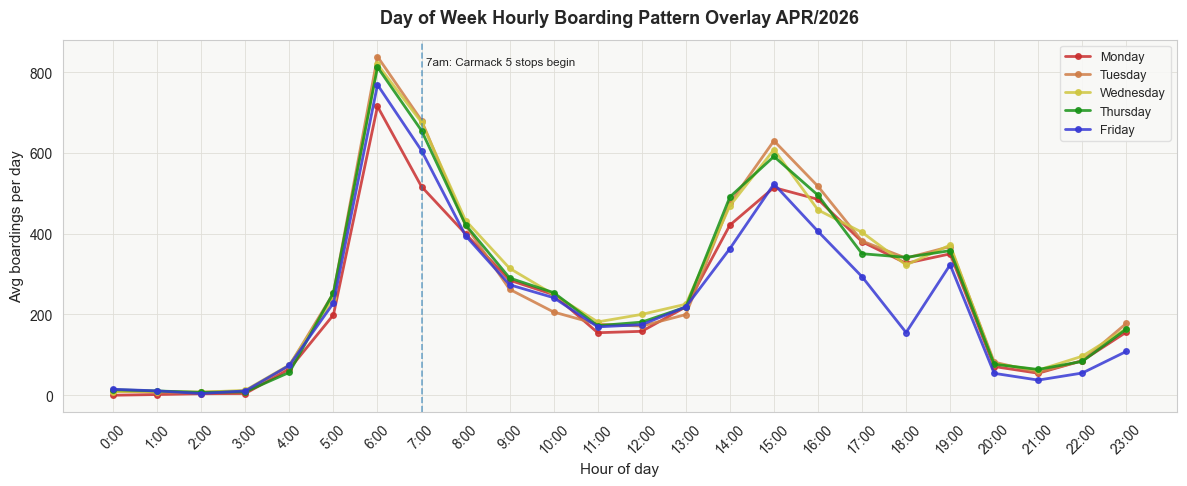

In [13]:
# set order and colors for days
colors = {
    'Monday': '#C92E2E',
    'Tuesday': '#CF7D46',
    'Wednesday': '#CFC640',
    'Thursday': '#179217',
    'Friday': '#3638D4'
}
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

# Subset data into hourly boardings by day of week
hourly_by_day = (
    mc_df[mc_df['weekday'].isin(day_order)]
    .groupby(['weekday', 'weekday_num', 'hour'])['boardings']
    .sum()
    .reset_index()
    .sort_values(['weekday_num', 'hour'])
)

# Normalize to per-occurrence average (divide by number of each weekday in sample)
day_counts = mc_df.groupby('weekday')['date'].apply(lambda x: x.dt.date.nunique())
hourly_by_day['avg_boardings'] = hourly_by_day.apply(
    lambda r: r['boardings'] / day_counts.get(r['weekday'], 1), axis=1
)

fig, ax = plt.subplots(figsize=(12, 5))

for day in day_order:
    subset = hourly_by_day[(hourly_by_day['weekday'] == day)]
    color = colors[day]

    ax.plot(subset['hour'], subset['avg_boardings'], marker='o', markersize=4, linewidth=2, color=color, label=day, alpha=0.85)

# Indicate when carmack 5 stops begin
ax.axvline(x=CARMACK_5_BEGINS, linewidth=1.2,
           linestyle='--', alpha=0.6)
ax.text(CARMACK_5_BEGINS + 0.1, ax.get_ylim()[1] * 0.95,
        '7am: Carmack 5 stops begin', fontsize=8.5, va='top')

ax.set_xticks(range(hourly_by_day['hour'].min(), hourly_by_day['hour'].max() + 1))
ax.set_xticklabels([f'{h}:00' for h in range(hourly_by_day['hour'].min(), hourly_by_day['hour'].max() + 1)],
                    rotation=45)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Avg boardings per day')
ax.set_title(f'Day of Week Hourly Boarding Pattern Overlay {MONTH}/{YEAR}', pad=12)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9, edgecolor='#ddd')

plt.tight_layout()
# plt.savefig(f'2_hourly_boardings_by_day_{MONTH}_{YEAR}.png', dpi=150, bbox_inches='tight')
plt.show()

### **Interpretation**

The days of the week have generally the same curve. The morning hour has a clear steep peak at 0600. Afternoon peak is visivle again, peaking at 1500 with a more shallow descent until the 2000 hour. There is a statistically significant drop in boardings at the 1800 hour for Fridays. This is likely due to on site parking opening up for weekend staffing at this time. Due to staffing strategy and since the demand "peaks" again at 1900 to match the other days, my recommendation would be to not consider this in staffing the shuttle. 

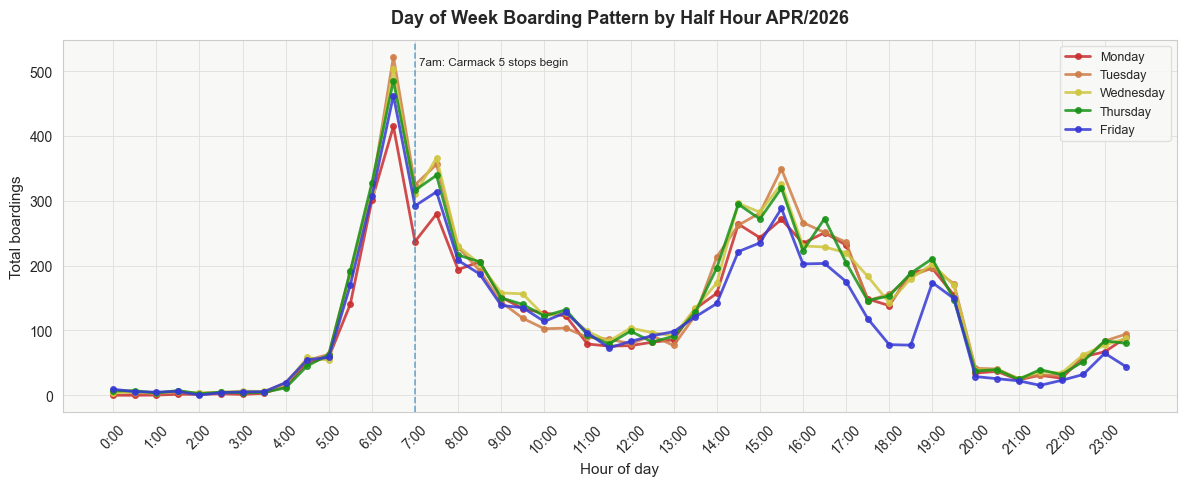

In [14]:
# same plot BUT split by half hour
# set order and colors for days
colors = {
    'Monday': '#C92E2E',
    'Tuesday': '#CF7D46',
    'Wednesday': '#CFC640',
    'Thursday': '#179217',
    'Friday': '#3638D4'
}
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

# create half hour col
mc_df['half_hour'] = (mc_df['minute'] // 30) * 30

# Subset data into half-hourly boardings by day of week
half_hourly_by_day = (
    mc_df[mc_df['weekday'].isin(day_order)]
    .groupby(['weekday', 'weekday_num', 'hour', 'half_hour'])['boardings']
    .sum()
    .reset_index()
    .sort_values(['weekday_num', 'hour', 'half_hour'])
)

# Normalize to per-occurrence average (divide by number of each weekday in sample)
day_counts = mc_df.groupby('weekday')['date'].apply(lambda x: x.dt.date.nunique())
half_hourly_by_day['avg_boardings'] = half_hourly_by_day.apply(
    lambda r: r['boardings'] / day_counts.get(r['weekday'], 1), axis=1
)

fig, ax = plt.subplots(figsize=(12, 5))

for day in day_order:
    subset = half_hourly_by_day[(half_hourly_by_day['weekday'] == day)]
    color = colors[day]

    ax.plot(subset['hour'] + subset['half_hour'] / 60, subset['avg_boardings'], marker='o', markersize=4, linewidth=2, color=color, label=day, alpha=0.85)

# Indicate when carmack 5 stops begin
ax.axvline(x=CARMACK_5_BEGINS, linewidth=1.2,
           linestyle='--', alpha=0.6)
ax.text(CARMACK_5_BEGINS + 0.1, ax.get_ylim()[1] * 0.95,
        '7am: Carmack 5 stops begin', fontsize=8.5, va='top')

ax.set_xticks(range(half_hourly_by_day['hour'].min(), half_hourly_by_day['hour'].max() + 1))
ax.set_xticklabels([f'{h}:00' for h in range(half_hourly_by_day['hour'].min(), half_hourly_by_day['hour'].max() + 1)],
                    rotation=45)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Total boardings')
ax.set_title(f'Day of Week Boarding Pattern by Half Hour {MONTH}/{YEAR}', pad=12)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9, edgecolor='#ddd')

plt.tight_layout()
# plt.savefig(f'2_half_hourly_boardings_by_day_{MONTH}_{YEAR}.png', dpi=150, bbox_inches='tight')
plt.show()


---

## Visualization 3: Stop by Stop Boarding

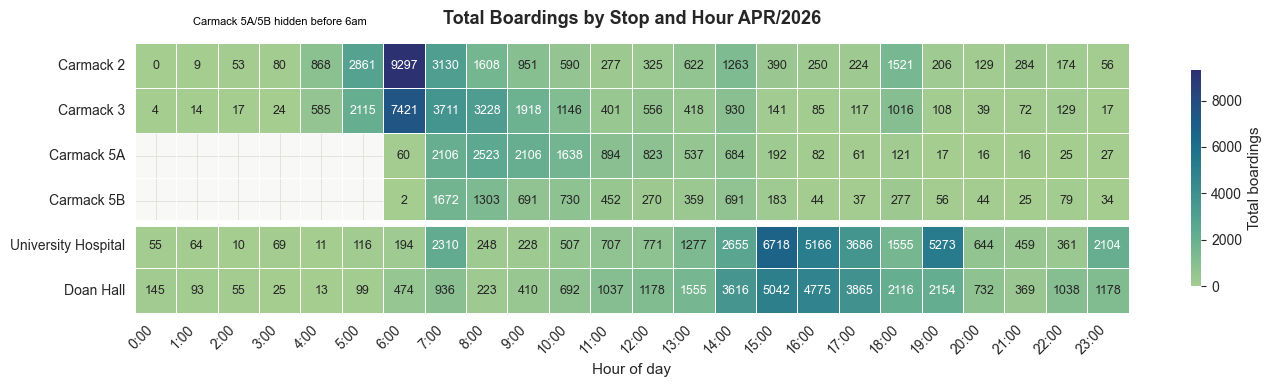

In [15]:
# create a df with hourly boardings by stop
hourly_by_stop = (
    mc_df.groupby(['stop_name', 'hour'])['boardings']
    .sum()
    .reset_index()
    .astype({'boardings': float})
 )

# Hide Carmack 5A/5B cells before 6am in the heatmap
hide_mask = hourly_by_stop['stop_name'].isin(['Carmack 5A', 'Carmack 5B']) & (hourly_by_stop['hour'] < 6)
hourly_by_stop.loc[hide_mask, 'boardings'] = np.nan

# order the stops
stops_order = ['Carmack 2', 'Carmack 3', 'Carmack 5A', 'Carmack 5B', 'University Hospital', 'Doan Hall'] 

pivot = (
    hourly_by_stop
    .pivot(index='stop_name', columns='hour', values='boardings')
    .reindex(stops_order)
)
mask = pivot.isna()

fig, ax = plt.subplots(figsize=(14, 4))

sns.heatmap(
    pivot,
    ax=ax,
    cmap='crest',
    linewidths=0.4,
    linecolor='white',
    annot=True,
    fmt='.0f', 
    annot_kws={'size': 9},
    cbar_kws={'label': 'Total boardings', 'shrink': 0.8},
    mask=mask
)

# Draw divider between parking and med-center rows
parking_rows = sum(1 for r in stops_order if 'Carmack' in r and r in hourly_by_stop['stop_name'].unique())
ax.axhline(y=parking_rows, color='white', linewidth=5)

ax.text(3.5, -0.4, 'Carmack 5A/5B hidden before 6am', ha='center', fontsize=8, color='black', zorder=6)

ax.set_xticklabels([f'{h}:00' for h in pivot.columns], rotation=45, ha='right')
ax.set_xlabel('Hour of day')
ax.set_ylabel('')
ax.set_title(f'Total Boardings by Stop and Hour {MONTH}/{YEAR}', pad=14)

plt.tight_layout()
# plt.savefig(f'3_hourly_boardings_by_stop_{MONTH}_{YEAR}.png', dpi=150, bbox_inches='tight')
plt.show()

### **Interpretation:**

- 9am hour drops to 3 busses. 
- 


---

## Visualization 3a: Mosaic Plot of Stop Traffic

c:\Users\morgan.1461\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\graphics\mosaicplot.py:651: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Rect = Rectangle((x, y), w, h, label=text, **props)


(<Figure size 640x480 with 3 Axes>,
 {('Inbound', 'Carmack 2'): (0.0,
   np.float64(0.0),
   0.49487675757328087,
   np.float64(0.34546120058565155)),
  ('Inbound', 'Carmack 3'): (0.0,
   np.float64(0.3579612005856515),
   0.49487675757328087,
   np.float64(0.3323389458272328)),
  ('Inbound', 'Carmack 5A'): (0.0,
   np.float64(0.7028001464128842),
   0.49487675757328087,
   np.float64(0.1638222913616399)),
  ('Inbound', 'Carmack 5B'): (0.0,
   np.float64(0.8791224377745243),
   0.49487675757328087,
   np.float64(0.0958775622254758)),
  ('Inbound', 'Doan Hall'): (0.0,
   np.float64(0.9874999999999999),
   0.49487675757328087,
   np.float64(0.0)),
  ('Inbound', 'University Hospital'): (0.0,
   np.float64(1.0),
   0.49487675757328087,
   np.float64(0.0)),
  ('Outbound', 'Carmack 2'): (0.5144846007105358,
   np.float64(0.0),
   0.4855153992894642,
   np.float64(0.0)),
  ('Outbound', 'Carmack 3'): (0.5144846007105358,
   np.float64(0.012499999999999999),
   0.4855153992894642,
   np.float64

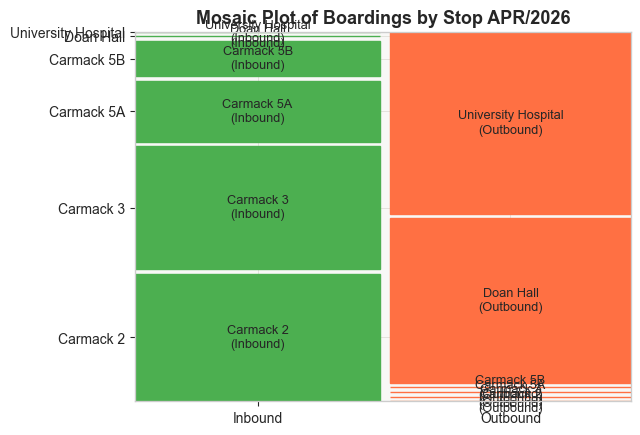

In [16]:
# no seaborn for mosaic plots
# build direction labels so inbound/outbound stops are their own rows
from statsmodels.graphics.mosaicplot import mosaic

mosaic_mc_df = (
    mc_df.groupby(['direction', 'stop_name'], observed=True)['boardings']
    .sum()
    .reset_index()
)

inbound_stops = [
    'Carmack 2',
    'Carmack 3',
    'Carmack 5A',
    'Carmack 5B'
]

outbound_stops = [
    'University Hospital',
    'Doan Hall'
]

mosaic_mc_df = mc_df[
    ((mc_df['direction'] == 'Inbound') & (mc_df['stop_name'].isin(inbound_stops))) |
    ((mc_df['direction'] == 'Outbound') & (mc_df['stop_name'].isin(outbound_stops)))
].groupby(['direction', 'stop_name'], observed=True)['boardings'].sum().reset_index()

mosaic_mc_df = mosaic_mc_df.sort_values(['direction', 'stop_name'])

mosaic_data = (
    mosaic_mc_df
    .set_index(['direction', 'stop_name'])['boardings']
    .to_dict()
)

# control function over formatting
def labelizer(key):
    direction, stop = key
    return f'{stop}\n({direction})'

def props(key):
    direction, stop = key
    return {
        'color': '#4CAF50' if direction == 'Inbound' else '#FF7043',
        'edgecolor': 'white'
    }

mosaic(
    mosaic_data,
    labelizer=labelizer,
    properties=props,
    title=f'Mosaic Plot of Boardings by Stop {MONTH}/{YEAR}',
    gap=0.02
)



---

## Visualization 4: Boarding Direction Split

In [17]:
# Bus load metric: average boardings per completed trip, split inbound vs outbound
# BUS_CAPACITY_COMFORT is the comfortable threshold of 50 passengers on a bus.

# inbound vs outbound stops
# inbound: all carmack
INBOUND_STOPS = {
    'Carmack 2': 403,
    'Carmack 3': 404,
    'Carmack 5A': 94,
    'Carmack 5B': 95
}

# outbound: doan and uh
OUTBOUND_STOPS = {
    'Doan Hall': 37,
    'University Hospital': 401
}

# stop_id lookup
inbound_ids = set(INBOUND_STOPS.values())
outbound_ids = set(OUTBOUND_STOPS.values())
expected_stop_counts = {
    'Inbound': len(inbound_ids),
    'Outbound': len(outbound_ids)
}

trip_events = (
    mc_df[mc_df['stop_id'].isin(inbound_ids | outbound_ids)]
    .sort_values(['date', 'run_id', 'time', 'stop_id'])
    .copy()
)

trip_events['direction'] = trip_events['stop_id'].apply(
    lambda s: 'Inbound' if s in inbound_ids else 'Outbound'
)

# Stop-level metric: average boardings contributed by each bus at each stop within each hour.
per_stop_hour = (
    trip_events.groupby(['date', 'run_id', 'stop_id', 'direction', 'hour'], as_index=False)
    .agg(total_boardings=('boardings', 'sum'))
)

avg_boardings_per_bus = (
    per_stop_hour.groupby(['stop_id', 'direction', 'hour'], as_index=False)
    .agg(
        avg_boardings_per_bus=('total_boardings', 'mean'),
        n_observations=('total_boardings', 'count')
    )
    .sort_values(['direction', 'stop_id', 'hour'])
)

def assign_trip_ids(group):
    group = group.sort_values(['time', 'stop_id']).copy()
    trip_number = 0
    seen_stops = set()
    trip_ids = []

    for stop_id in group['stop_id']:
        if stop_id in seen_stops:
            trip_number += 1
            seen_stops = set()
        trip_ids.append(trip_number)
        seen_stops.add(stop_id)

    group['trip_id'] = trip_ids
    return group

# Build actual trip units across the full ordered run, not inside hour buckets.
trip_groups = []
for (date, run_id, direction), group in trip_events.groupby(['date', 'run_id', 'direction'], sort=False):
    group = assign_trip_ids(group)
    group['date'] = date
    group['run_id'] = run_id
    group['direction'] = direction
    trip_groups.append(group)

trip_events = pd.concat(trip_groups, ignore_index=True)

ib_ob_trip_boardings = (
    trip_events.groupby(['date', 'run_id', 'direction', 'trip_id'], as_index=False)
    .agg(
        trip_start=('time', 'min'),
        trip_end=('time', 'max'),
        total_trip_boardings=('boardings', 'sum'),
        stop_visits=('stop_id', 'count'),
        unique_stop_count=('stop_id', 'nunique')
    )
    .assign(
        expected_stop_count=lambda d: d['direction'].map(expected_stop_counts),
        is_complete_trip=lambda d: d['unique_stop_count'] == d['expected_stop_count'],
        hour=lambda d: d['trip_end'].dt.hour
    )
)

completed_trips = ib_ob_trip_boardings[ib_ob_trip_boardings['is_complete_trip']].copy()

direction_hourly = (
    completed_trips.groupby(['direction', 'hour'], as_index=False)
    .agg(
        avg_direction_boardings_per_trip=('total_trip_boardings', 'mean'),
        trips_observed=('trip_id', 'count')
    )
    .assign(
        percent_of_capacity=lambda d: (d['avg_direction_boardings_per_trip'] / BUS_CAPACITY_COMFORT) * 100
    )
    .sort_values(['direction', 'hour'])
)

print(f'Completed trips retained: {len(completed_trips):,} of {len(ib_ob_trip_boardings):,}')
#display(direction_hourly)
print(f'Max completed-trip boardings: {completed_trips["total_trip_boardings"].max()}')
#display(completed_trips.nlargest(5, 'total_trip_boardings'))

Completed trips retained: 12,040 of 13,500
Max completed-trip boardings: 63


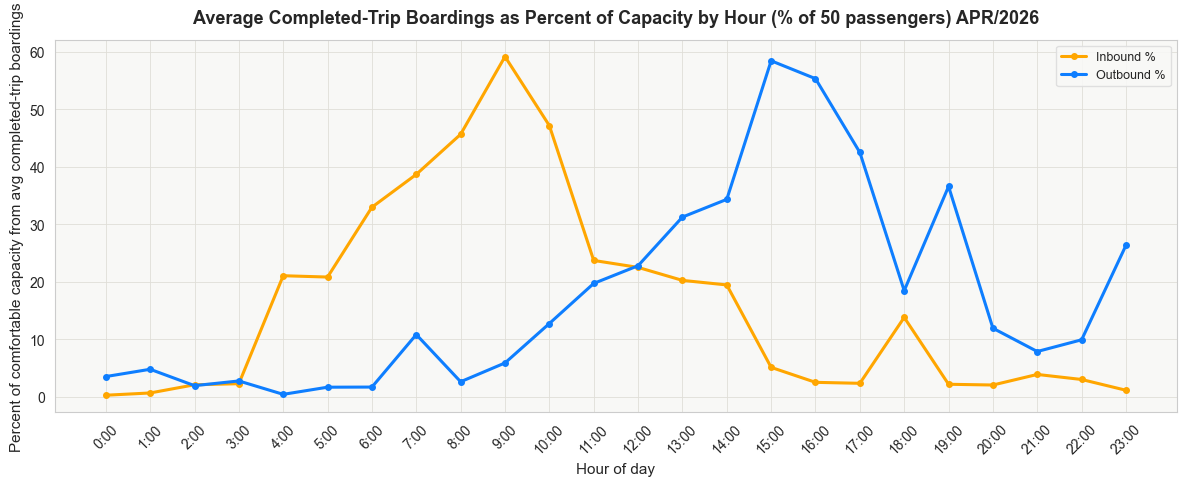

In [18]:
# viz
fig, ax = plt.subplots(figsize=(12, 5))

for direction, line_color in [('Inbound', "#ffa600"), ('Outbound', "#0e7eff")]:
    subset = direction_hourly[direction_hourly['direction'] == direction]
    ax.plot(
        subset['hour'],
        subset['percent_of_capacity'],
        marker='o',
        markersize=4,
        linewidth=2.2,
        color=line_color,
        label=f'{direction} %'
    )

ax.set_xticks(range(direction_hourly['hour'].min(), direction_hourly['hour'].max() + 1))
ax.set_xticklabels([f'{h}:00' for h in range(direction_hourly['hour'].min(), direction_hourly['hour'].max() + 1)],
                    rotation=45)

ax.set_xlabel('Hour of day')
ax.set_ylabel('Percent of comfortable capacity from avg completed-trip boardings')
ax.set_title(f'Average Completed-Trip Boardings as Percent of Capacity by Hour (% of 50 passengers) {MONTH}/{YEAR}', pad=12)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9, edgecolor='#ddd')

plt.tight_layout()
# plt.savefig(f'4_average_completed_trip_boardings_percent_capacity_{MONTH}_{YEAR}.png', dpi=150, bbox_inches='tight')
plt.show()
# direction_hourly

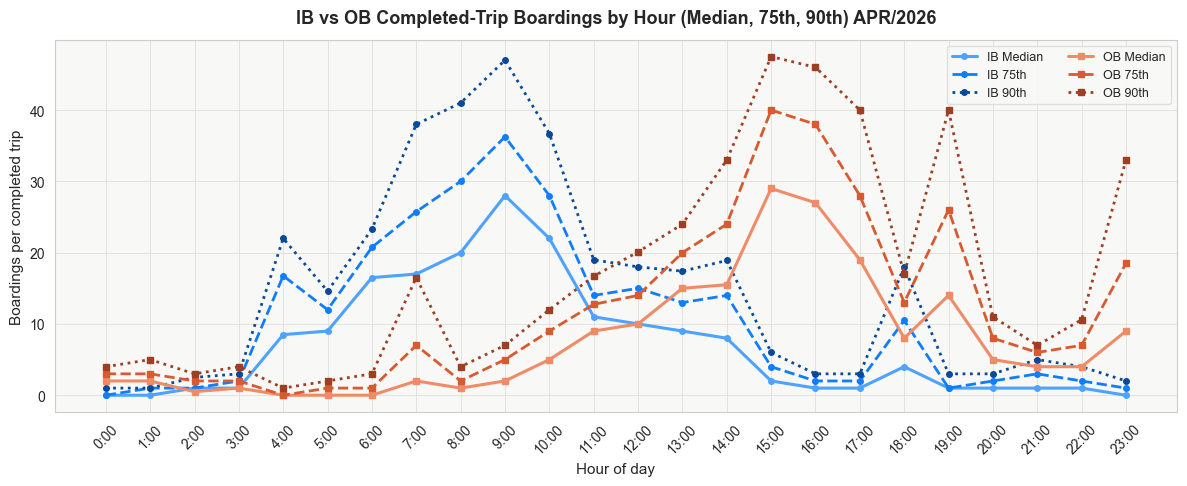

In [19]:
# viz: percentile trend lines of completed-trip bus load (IB vs OB)
percentiles_by_direction_hour = (
    completed_trips.groupby(['direction', 'hour'])['total_trip_boardings']
    .agg(
        median_boardings='median',
        p75_boardings=lambda x: x.quantile(0.75),
        p90_boardings=lambda x: x.quantile(0.90)
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))

styles = {
    'Inbound': {
        'median': {'color': '#4da3ff', 'linestyle': '-', 'marker': 'o', 'label': 'IB Median'},
        'p75': {'color': '#0e7eff', 'linestyle': '--', 'marker': 'o', 'label': 'IB 75th'},
        'p90': {'color': '#084a99', 'linestyle': ':', 'marker': 'o', 'label': 'IB 90th'}
    },
    'Outbound': {
        'median': {'color': '#f08b68', 'linestyle': '-', 'marker': 's', 'label': 'OB Median'},
        'p75': {'color': '#D85A30', 'linestyle': '--', 'marker': 's', 'label': 'OB 75th'},
        'p90': {'color': '#9e3f23', 'linestyle': ':', 'marker': 's', 'label': 'OB 90th'}
    }
}

for direction in ['Inbound', 'Outbound']:
    subset = percentiles_by_direction_hour[percentiles_by_direction_hour['direction'] == direction]
    if subset.empty:
        continue

    style = styles[direction]
    ax.plot(subset['hour'], subset['median_boardings'], linewidth=2.2, markersize=4, **style['median'])
    ax.plot(subset['hour'], subset['p75_boardings'], linewidth=2.0, markersize=4, **style['p75'])
    ax.plot(subset['hour'], subset['p90_boardings'], linewidth=2.0, markersize=4, **style['p90'])

hours = sorted(percentiles_by_direction_hour['hour'].unique())
if hours:
    ax.set_xticks(range(min(hours), max(hours) + 1))
    ax.set_xticklabels([f'{h}:00' for h in range(min(hours), max(hours) + 1)], rotation=45)

ax.set_xlabel('Hour of day')
ax.set_ylabel('Boardings per completed trip')
ax.set_title(f'IB vs OB Completed-Trip Boardings by Hour (Median, 75th, 90th) {MONTH}/{YEAR}', pad=12)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9, edgecolor='#ddd', ncol=2)

plt.tight_layout()
plt.show()

### Interpretation:

- There is 2x buses running at the 6-8a hour leading to lower boardings per trip and when the buses drop at 9am there is the peak of boardings due to buses dropping out of service at the 9am hour.

,date,stop_id,boardings,alightings,run_id,arrival,departure,dwell,hour,minute,time,stop_name,weekday,dwell_sec,weekday_num,direction,half_hour
24476,2026-04-01,94,0,1,1501,1900-01-01 00:00:31,1900-01-01 00:00:56,0 days 00:00:25,0,0,2026-04-01 00:00:31,Carmack 5A,Wednesday,25.0,2,Inbound,0
10598,2026-04-01,403,0,0,1502,1900-01-01 00:01:44,1900-01-01 00:01:53,0 days 00:00:09,0,1,2026-04-01 00:01:44,Carmack 2,Wednesday,9.0,2,Inbound,0
7712,2026-04-01,401,2,14,1503,1900-01-01 00:02:29,1900-01-01 00:03:11,0 days 00:00:42,0,2,2026-04-01 00:02:29,University Hospital,Wednesday,42.0,2,Outbound,0
7713,2026-04-01,37,1,0,1503,1900-01-01 00:03:14,1900-01-01 00:04:05,0 days 00:00:51,0,3,2026-04-01 00:03:14,Doan Hall,Wednesday,51.0,2,Outbound,0
10599,2026-04-01,404,0,0,1502,1900-01-01 00:03:27,1900-01-01 00:03:55,0 days 00:00:28,0,3,2026-04-01 00:03:27,Carmack 3,Wednesday,28.0,2,Inbound,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18015,2026-04-30,401,1,0,1502,1900-01-01 23:55:42,1900-01-01 23:56:36,0 days 00:00:54,23,55,2026-04-30 23:55:42,University Hospital,Thursday,54.0,3,Outbound,30
18016,2026-04-30,37,0,0,1502,1900-01-01 23:56:39,1900-01-01 23:57:30,0 days 00:00:51,23,56,2026-04-30 23:56:39,Doan Hall,Thursday,51.0,3,Outbound,30
7711,2026-04-30,95,0,0,1504,1900-01-01 23:57:48,1900-01-01 23:58:03,0 days 00:00:15,23,57,2026-04-30 23:57:48,Carmack 5B,Thursday,15.0,3,Inbound,30
3806,2026-04-30,403,0,0,1501,1900-01-01 23:58:02,1900-01-01 23:58:18,0 days 00:00:16,23,58,2026-04-30 23:58:02,Carmack 2,Thursday,16.0,3,Inbound,30


Text(0.5, 1.0, 'Unique Runs Observed by Hour')

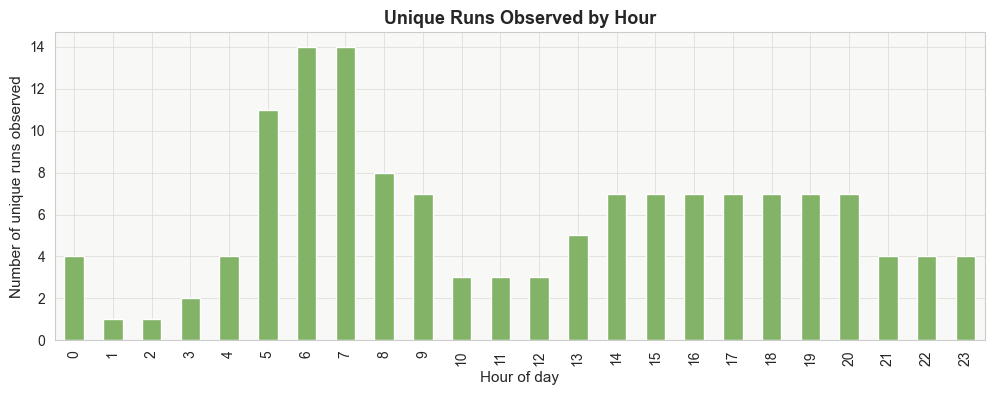

In [20]:
# find the number of unique runs observed in each hour
display(mc_df)

bus_counts = (
    mc_df.groupby('hour')['run_id']
    .nunique()
    .reindex(range(24), fill_value=0)
)

bus_counts.plot(kind='bar', color='#82b366', figsize=(12, 4))
plt.xlabel('Hour of day')
plt.ylabel('Number of unique runs observed')
plt.title('Unique Runs Observed by Hour')



---

## Visualization 5: Recommended Buses Per Hour

Goal is a model predicting how many busses should be run per hour to handle the capacity at each timeframe

In [21]:
# constants
IDEAL_CAPACITY = 50 # what is a 'comfortable' load
MAX_CAPACITY = 65 # over 65 passengers is considered overcapacity
FULL_LOOP_TIME_MIN = 20
CURRENT_HEADWAY_TARGETS = { # from headway targets in monthly dashboard
    0: 20, # 12am
    1: 20, # 1am
    2: 20, # 2am
    3: 20, # 3am
    4: 20, # 4am
    5: 10, # 5am
    6: 3, # 6am
    7: 3, # 7am
    8: 10, # 8am
    9: 10, # 9am
    10: 10, # 10am
    11: 10, # 11am
    12: 10, # 12pm
    13: 10, # 1pm
    14: 5, # 2pm
    15: 5, # 3pm
    16: 3, # 4pm
    17: 3, # 5pm
    18: 5, # 6pm
    19: 5, # 7pm
    20: 10, # 8pm
    21: 10, # 9pm
    22: 5, # 10pm
    23: 5 # 11pm
}

# Passenger demand is generally very consistent from day to day
# hourly_mc_df

### XGBoost Model for Predicting Bus Demand per Hour

This model is a machine learning ttechnique that uses gradient boosted decision trees. 

In [22]:
#%pip install xgboost scikit-learn

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [23]:
hourly_mc_df  # base table used for bus recommendation modeling

# Convert sampled totals into a typical service-day hourly demand.
service_days = mc_df["date"].dt.date.nunique()
hourly_mc_df["avg_boardings_per_day"] = hourly_mc_df["total_boardings"] / service_days

# Estimate hourly carrying capacity per bus from loop time.
trips_per_bus_per_hour = max(1, int(round(60 / FULL_LOOP_TIME_MIN)))
passengers_per_bus_per_hour = IDEAL_CAPACITY * trips_per_bus_per_hour

# Volume-based recommendation (kept for comparison).
hourly_mc_df["volume_buses_needed"] = np.ceil(
    hourly_mc_df["avg_boardings_per_day"] / passengers_per_bus_per_hour
).astype(int)
hourly_mc_df["volume_buses_needed"] = hourly_mc_df["volume_buses_needed"].clip(lower=1)

# Observed reality: buses in service by hour = unique run_id count in that hour.
observed_buses_by_hour = (
    mc_df.groupby("hour")["run_id"]
    .nunique()
    .reindex(hourly_mc_df["hour"], fill_value=0)
    .astype(int)
    .values
)
hourly_mc_df["observed_buses"] = observed_buses_by_hour

# Use observed buses as the target requested.
hourly_mc_df["buses_needed"] = hourly_mc_df["observed_buses"]

# Time structure is cyclical - 11pm and 12am are adjacent.
hourly_mc_df["hour_sin"] = np.sin(2 * np.pi * hourly_mc_df["hour"] / 24)
hourly_mc_df["hour_cos"] = np.cos(2 * np.pi * hourly_mc_df["hour"] / 24)

# Additional predictors from observed operations.
hourly_mc_df["net_flow"] = hourly_mc_df["total_boardings"] - hourly_mc_df["total_alightings"]
hourly_mc_df["flow_ratio"] = hourly_mc_df["total_boardings"] / (hourly_mc_df["total_alightings"] + 1)
hourly_mc_df["dwell_log"] = np.log1p(hourly_mc_df["avg_dwell_sec"])

features = [
    "avg_boardings_per_day",
    "total_alightings",
    "avg_dwell_sec",
    "hour_sin",
    "hour_cos",
    "net_flow",
    "flow_ratio",
    "dwell_log"
 ]

X = hourly_mc_df[features]
y = hourly_mc_df["buses_needed"]

In [24]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

model.fit(X, y)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.9
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [25]:
hourly_mc_df["pred_buses_needed"] = np.ceil(model.predict(X)).astype(int)
hourly_mc_df["pred_buses_needed"] = hourly_mc_df["pred_buses_needed"].clip(lower=1)

hourly_mc_df[[
    "hour",
    "avg_boardings_per_day",
    "observed_buses",
    "pred_buses_needed"
 ]].sort_values("hour")

,hour,avg_boardings_per_day,observed_buses,pred_buses_needed
0,0,9.681818,4,4
1,1,8.181818,1,2
2,2,6.136364,1,1
3,3,9.181818,2,3
4,4,68.500000,4,5
5,5,235.954545,11,11
6,6,793.090909,14,15
7,7,630.227273,14,14
8,8,415.136364,8,8
9,9,286.545455,7,7


**Interpretation:**

The observed busses col is the actual amount of observed busses given the hour. The model is capturing the current operating pattern well, but is quite overkill


---

## Visualization 6: Headway by Time of Day



In [26]:
# break out the average headway by hour
# after break out by stop?

hw_df = mc_df.copy()

# split into each individual stop and sort by time
# them calculate the headway for each row by taking difference between current row arrival and previous row arrival
uh_hw_df = hw_df[hw_df['stop_id'] == 401].sort_values(['date', 'time']).copy()
uh_hw_df['headway'] = uh_hw_df['arrival'] - uh_hw_df['arrival'].shift(1)

doan_hw_df = hw_df[hw_df['stop_id'] == 37].sort_values(['date', 'time']).copy()
doan_hw_df['headway'] = doan_hw_df['arrival'] - doan_hw_df['arrival'].shift(1)

carmack_2_hw_df = hw_df[hw_df['stop_id'] == 403].sort_values(['date', 'time']).copy()
carmack_2_hw_df['headway'] = carmack_2_hw_df['arrival'] - carmack_2_hw_df['arrival'].shift(1)

carmack_3_hw_df = hw_df[hw_df['stop_id'] == 404].sort_values(['date', 'time']).copy()
carmack_3_hw_df['headway'] = carmack_3_hw_df['arrival'] - carmack_3_hw_df['arrival'].shift(1)

carmack_5a_hw_df = hw_df[hw_df['stop_id'] == 94].sort_values(['date', 'time']).copy()
carmack_5a_hw_df['headway'] = carmack_5a_hw_df['arrival'] - carmack_5a_hw_df['arrival'].shift(1)

carmack_5b_hw_df = hw_df[hw_df['stop_id'] == 95].sort_values(['date', 'time']).copy()
carmack_5b_hw_df['headway'] = carmack_5b_hw_df['arrival'] - carmack_5b_hw_df['arrival'].shift(1)

#NOTE: Can remove carmack 5a and 5b 
# carmack_5b_hw_df['headway'].describe()
# combine all individual stop dfs
total_hw_df = pd.concat([
    uh_hw_df,
    doan_hw_df,
    carmack_2_hw_df,
    carmack_3_hw_df,
    carmack_5a_hw_df,
    carmack_5b_hw_df
], ignore_index=True)

# total_hw_df['headway'].describe()

# remove any true outlier headways > 25 min, entire loop w one bus should take ~20 mins, so this is a good maximum 
total_hw_df = total_hw_df[total_hw_df['headway'] <= pd.Timedelta(minutes=25)]
# remove any potential negative headways due to data issues
total_hw_df = total_hw_df[total_hw_df['headway'] >= pd.Timedelta(seconds=0)]

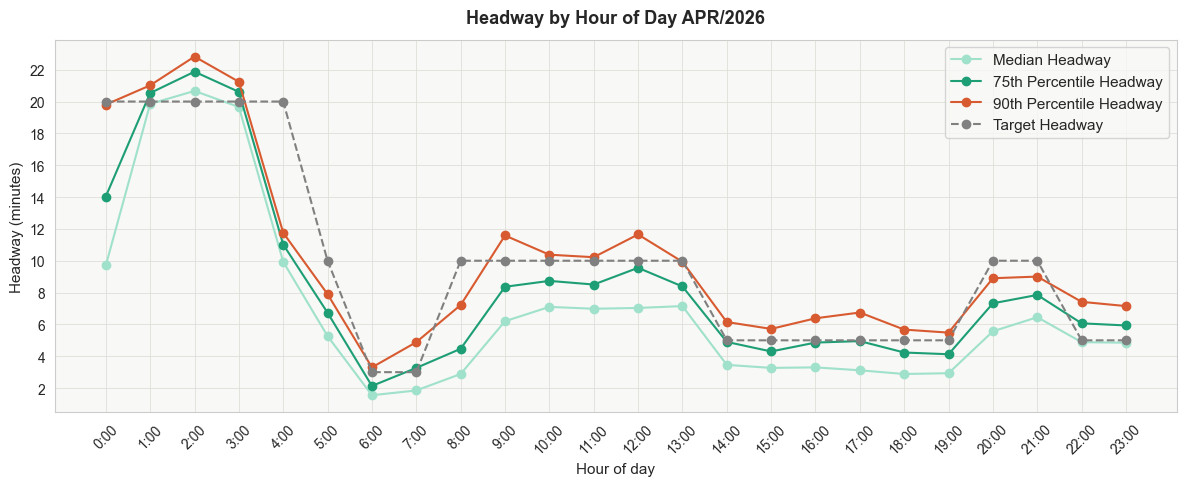

In [27]:
# group headways by hour and plot the 50th percentile, 75th percentile, and 90th percentile headway for each hour to see how headways fluctuate across the day
headway_by_hour = (
    total_hw_df.groupby('hour')['headway']
    .agg(
        median_headway=lambda x: x.median().total_seconds() / 60,
        p75_headway=lambda x: x.quantile(0.75).total_seconds() / 60,
        p90_headway=lambda x: x.quantile(0.90).total_seconds() / 60,
        max_headway=lambda x: x.max().total_seconds() / 60
    )
    .reset_index()
)

# create target headways based on current targets in dashboard
# NOTE: Set 20 minute headway target for 12am-5am
TARGET_HEADWAYS = {
    0: 20,
    1: 20,
    2: 20,
    3: 20,
    4: 20,
    5: 10,
    6: 3,
    7: 3,
    8: 10,
    9: 10,
    10: 10,
    11: 10,
    12: 10,
    13: 10,
    14: 5,
    15: 5,
    16: 5,
    17: 5,
    18: 5,
    19: 5,
    20: 10,
    21: 10,
    22: 5,
    23: 5,
}

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(headway_by_hour['hour'], headway_by_hour['median_headway'], marker='o', label='Median Headway', color=LIGHT_TEAL)
ax.plot(headway_by_hour['hour'], headway_by_hour['p75_headway'], marker='o', label='75th Percentile Headway', color=TEAL)
ax.plot(headway_by_hour['hour'], headway_by_hour['p90_headway'], marker='o', label='90th Percentile Headway', color=CORAL)

# plot target headways
ax.plot(
    headway_by_hour['hour'],
    headway_by_hour['hour'].apply(lambda h: TARGET_HEADWAYS.get(h, None)),
    marker='o',
    label='Target Headway',
    color='gray',
    linestyle='--'
)

# ax.plot(headway_by_hour['hour'], headway_by_hour['max_headway'], marker='o', label='Max Headway')
ax.set_xticks(range(headway_by_hour['hour'].min(), headway_by_hour['hour'].max() + 1))
ax.set_xticklabels([f'{h}:00' for h in range(headway_by_hour['hour'].min(), headway_by_hour['hour'].max() + 1)], rotation=45)
ax.yaxis.set_major_locator(plt.MultipleLocator(2))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))
ax.set_xlabel('Hour of day')
ax.set_ylabel('Headway (minutes)')
ax.set_title(f'Headway by Hour of Day {MONTH}/{YEAR}', pad=12)
ax.legend()
plt.tight_layout()
# plt.savefig(f'5_headway_by_hour_{MONTH}_{YEAR}.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation:

- Anything below the dotted line is meeting the set target headway, anything above is not. 
- The 90th percentile headway is effectively representing the 'worst case scenario' in terms of headway at any given time. 
- This does not indicate anything specifically about demand, but rather if the busses are meeting the target headway times
- 7-8a is struggling to meet the headway about 25% of the time in March.
- The 10p-12a headway issue is clearly visible here with the median being at about exactly the tatget headway.
- Total headways should reflect individual stop headways as each stop is always stopped at

**In Practice:** If more target headways must be met, more busses should be run when the target headway is below the percentiles.
- For example; if a 5 minute headway is determined to be necessary for the 10p-12a timeframe, then more busses should be run at this time to reach this.
- Depending on the threshold that is willing to be set, the percent of headways met can be changed.
    - If it was decided that a headway being met 90% of the time is acceptable, then ideally the target line would follow the red 90th percentile line.

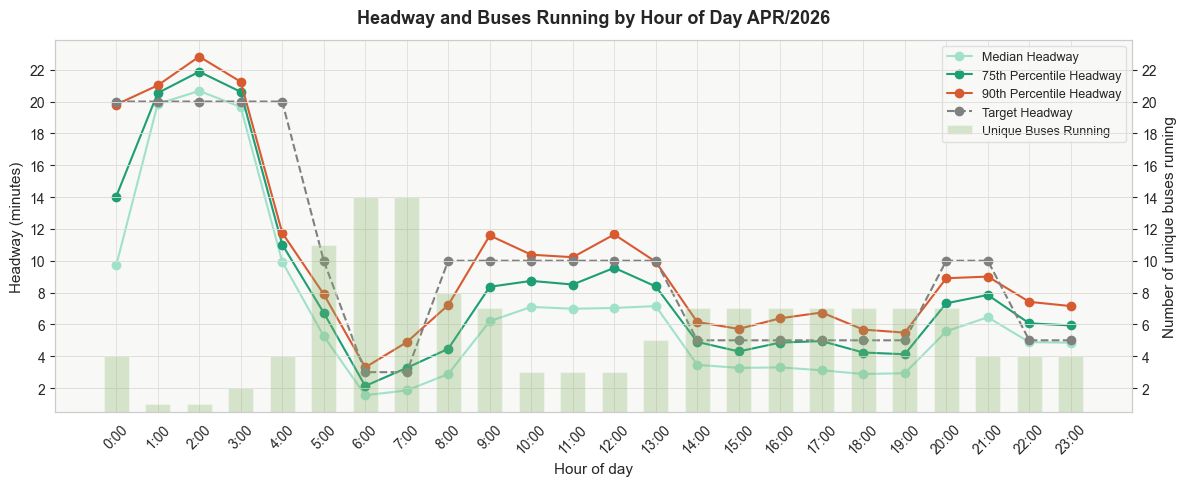

In [28]:
# overlay the bus counts on headway plt to illustrate the relationship 
fig, ax1 = plt.subplots(figsize=(12, 5))

# headway lines on primary axis
ax1.plot(headway_by_hour['hour'], headway_by_hour['median_headway'], marker='o', label='Median Headway', color=LIGHT_TEAL)
ax1.plot(headway_by_hour['hour'], headway_by_hour['p75_headway'], marker='o', label='75th Percentile Headway', color=TEAL)
ax1.plot(headway_by_hour['hour'], headway_by_hour['p90_headway'], marker='o', label='90th Percentile Headway', color=CORAL)

# target headway line
ax1.plot(
    headway_by_hour['hour'],
    headway_by_hour['hour'].apply(lambda h: TARGET_HEADWAYS.get(h, None)),
    marker='o',
    label='Target Headway',
    color='gray',
    linestyle='--'
)

ax1.set_xticks(range(headway_by_hour['hour'].min(), headway_by_hour['hour'].max() + 1))
ax1.set_xticklabels([f'{h}:00' for h in range(headway_by_hour['hour'].min(), headway_by_hour['hour'].max() + 1)], rotation=45)
ax1.yaxis.set_major_locator(plt.MultipleLocator(2))
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))
ax1.set_xlabel('Hour of day')
ax1.set_ylabel('Headway (minutes)')
ax1.set_title(f'Headway and Buses Running by Hour of Day {MONTH}/{YEAR}', pad=12)

# secondary axis for bus counts
ax2 = ax1.twinx()
ax2.bar(
    bus_counts.index,
    bus_counts.values,
    color='#82b366',
    alpha=0.3,
    width=0.6,
    label='Unique Buses Running'
)
ax2.set_ylabel('Number of unique buses running')
ax2.yaxis.set_major_locator(plt.MultipleLocator(2))
ax2.set_ylim(ax1.get_ylim())
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))

# combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9, framealpha=0.9, edgecolor='#ddd')

plt.tight_layout()
plt.show()

### Interpretation: 

- Number of buses is negatively correlated with headway time as expected.
- Between 5am and midnight it is pretty safe to say that the absolute longest you will ever have to wait for a med center shuttle is about 10 minutes.

**Diminishing Returns:**
- For example; the 2pm-8pm hour, the median headway is consistently at ~3.5 minutes with 7 busses running the route
- The 6am-8am hour, the median headway is just under 2 minutes with 14 buses running.
    - This indicates that 7 more busses, drivers, etc. (2x the original amount) will not reduce the headway by 2x
- From an operational cost perspective, adding more busses does not seem worthwhile to reduce waiting times by a very small amount that would be likely unnoticable to the end users

Notes:

- Seems to reflect the "elevator" design problem and non-outlier complaints are a result of this phenomenon rather than actual poor performance in my opinion.
- https://signalvnoise.com/posts/1244-defining-the-problem-of-elevator-waiting-times
- I am not sure that anything will ever 'fix' the complaints about the med center shuttle
- Outlier events will happen and likely trigger a flood of complaints, however, these cannot be predicted and should not be accounted for in operational planning
    - Ex) if a unit has a training of 30 people that lets out at 3pm, this will flood the stop and likely trigger complaints of normal users expecting their typical time, etc.


---

## Visualization 7: Capacity Measurement



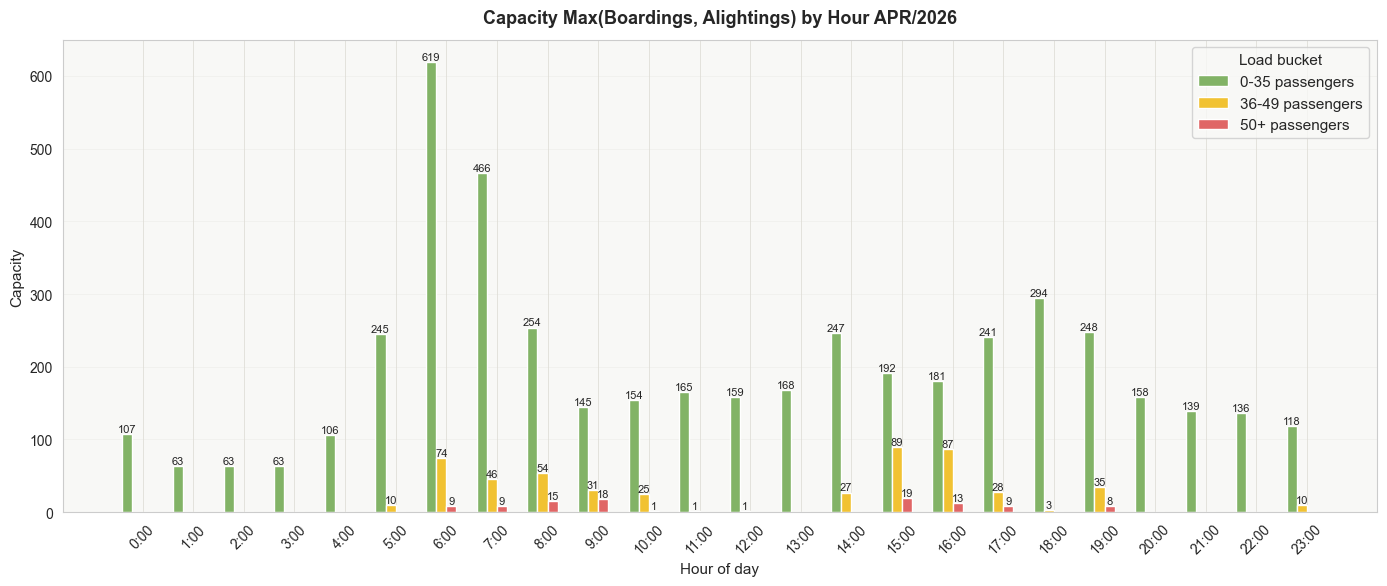

In [29]:
# create a capacity metric by hour in buckets of 0-30, 30-50, 50-65, and 65+ passengers
# using strict sequential UH -> Doan pairing (401 -> 37) per run/trip,
# aligned with combine_uh_doan logic
bins = [0, 36, 50, float('inf')]
labels = ['0-35', '36-49', '50+']

UH_STOP_ID = 401
DOAN_STOP_ID = 37
MAX_GAP_MINUTES = 10

# work on event-level data so pairs are built from adjacent sequential stops
pair_events = (
    trip_events
    .sort_values(['date', 'run_id', 'direction', 'trip_id', 'time'])
    .reset_index(drop=True)
    .copy()
)

paired_rows = []
i = 0

while i < len(pair_events):
    current = pair_events.iloc[i]

    if i + 1 >= len(pair_events):
        break

    nxt = pair_events.iloc[i + 1]

    same_keys = (
        current['date'] == nxt['date'] and
        current['run_id'] == nxt['run_id'] and
        current['direction'] == nxt['direction'] and
        current['trip_id'] == nxt['trip_id']
    )
    in_order = current['stop_id'] == UH_STOP_ID and nxt['stop_id'] == DOAN_STOP_ID
    gap = nxt['time'] - current['time']
    within_gap = pd.Timedelta(0) <= gap <= pd.Timedelta(minutes=MAX_GAP_MINUTES)

    if same_keys and in_order and within_gap:
        pair_boardings = current['boardings'] + nxt['boardings']
        pair_alightings = current['alightings'] + nxt['alightings']
        paired_rows.append({
            'date': current['date'],
            'run_id': current['run_id'],
            'direction': current['direction'],
            'trip_id': current['trip_id'],
            'hour': int(current['time'].hour),
            'uh_doan_pair_max_load': max(pair_boardings, pair_alightings)
        })
        i += 2
        continue

    i += 1

capacity_counts = pd.DataFrame(paired_rows)

if capacity_counts.empty:
    raise ValueError('No valid sequential UH->Doan pairs found. Check stop sequencing and time gaps.')

capacity_counts['capacity_bucket'] = pd.cut(
    capacity_counts['uh_doan_pair_max_load'],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

# count number of paired loads in each bucket per hour
capacity_by_hour = (
    capacity_counts.groupby(['hour', 'capacity_bucket'], observed=False)
    .size()
    .reset_index(name='load_count')
)

# ensure every hour has all 4 bucket columns (missing combos become 0)
hours = sorted(capacity_counts['hour'].unique())
capacity_pivot = (
    capacity_by_hour
    .pivot(index='hour', columns='capacity_bucket', values='load_count')
    .reindex(index=hours, columns=labels, fill_value=0)
)

# single grouped bar chart: each hour has one bar per bucket
bucket_colors = {
    '0-35': '#82b366',
    '36-49': '#f1c232',
    '50+': '#e06666'
}

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(capacity_pivot.index))
bar_width = 0.2

for idx, bucket in enumerate(labels):
    offsets = x + (idx - 1.5) * bar_width
    bars = ax.bar(
        offsets,
        capacity_pivot[bucket].values,
        width=bar_width,
        label=f'{bucket} passengers',
        color=bucket_colors[bucket]
    )

    # show value on each bar, but hide zeros
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.05,
                f'{int(height)}',
                ha='center',
                va='bottom',
                fontsize=8
            )

ax.set_xticks(x)
ax.set_xticklabels([f'{h}:00' for h in capacity_pivot.index], rotation=45)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Capacity')
ax.set_title(f'Capacity Max(Boardings, Alightings) by Hour {MONTH}/{YEAR}', pad=12)
ax.legend(title='Load bucket')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
# plt.savefig(f'7_capacity_max_boardings_alightings_grouped_bars_{MONTH}_{YEAR}.png', dpi=150, bbox_inches='tight')
plt.show()

Efficiency wise, a large green col with a small yellow col would indicate that there is 'too many' busses running, while a yellow bar that is simiilar in height could indicate that not enough are running?

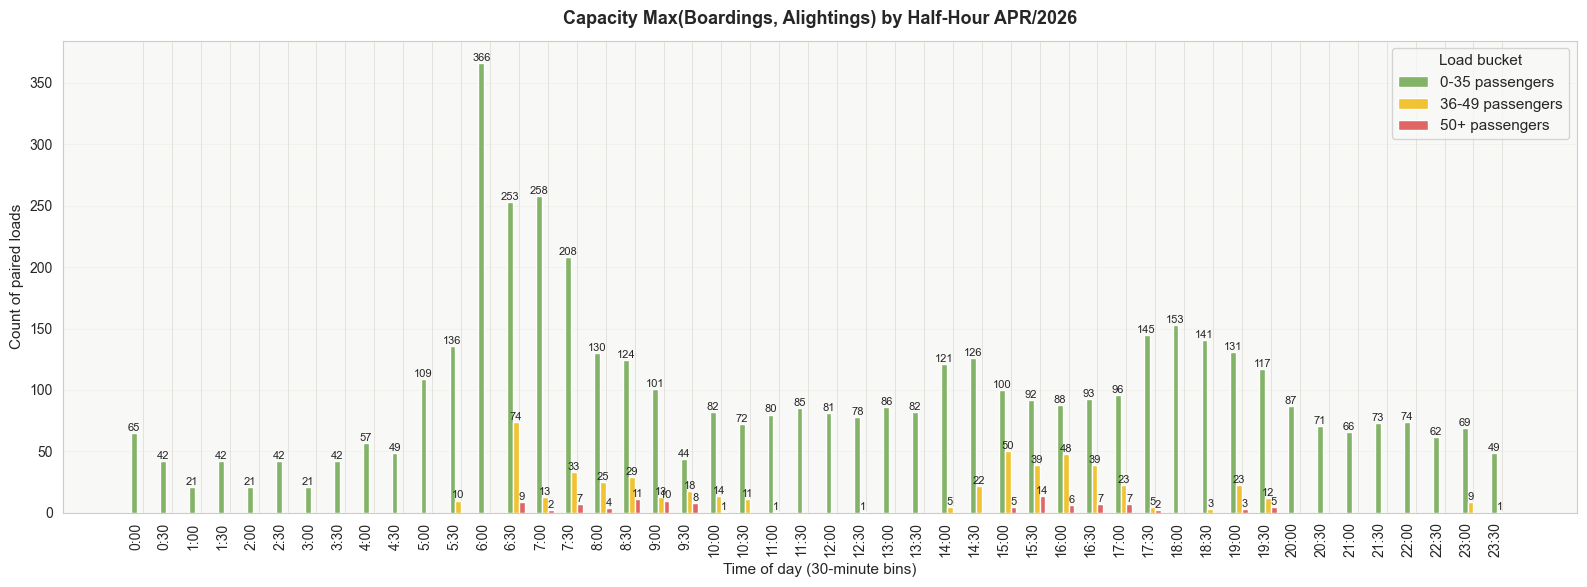

In [30]:
# SPLIT INTO HALF-HOUR INTERVALS
# create a capacity metric by half-hour-of-day in buckets of 0-29, 30-49, 50-64, and 65+ passengers
# using strict sequential UH -> Doan pairing (401 -> 37) per run/trip,
# aligned with combine_uh_doan logic
bins = [0, 36, 50, float('inf')]
labels = ['0-35', '36-49', '50+']

UH_STOP_ID = 401
DOAN_STOP_ID = 37
MAX_GAP_MINUTES = 10

# work on event-level data so pairs are built from adjacent sequential stops
pair_events = (
    trip_events
    .sort_values(['date', 'run_id', 'direction', 'trip_id', 'time'])
    .reset_index(drop=True)
    .copy()
)

paired_rows = []
i = 0

while i < len(pair_events):
    current = pair_events.iloc[i]

    if i + 1 >= len(pair_events):
        break

    nxt = pair_events.iloc[i + 1]

    same_keys = (
        current['date'] == nxt['date'] and
        current['run_id'] == nxt['run_id'] and
        current['direction'] == nxt['direction'] and
        current['trip_id'] == nxt['trip_id']
    )

    in_order = current['stop_id'] == UH_STOP_ID and nxt['stop_id'] == DOAN_STOP_ID
    gap = nxt['time'] - current['time']
    within_gap = pd.Timedelta(0) <= gap <= pd.Timedelta(minutes=MAX_GAP_MINUTES)

    if same_keys and in_order and within_gap:
        pair_boardings = current['boardings'] + nxt['boardings']
        pair_alightings = current['alightings'] + nxt['alightings']

        # Half-hour bucket as time-of-day only (not full date-time)
        half_hour = 30 if current['time'].minute >= 30 else 0
        time_bin = current['time'].hour + (half_hour / 60)

        paired_rows.append({
            'date': current['date'],
            'run_id': current['run_id'],
            'direction': current['direction'],
            'trip_id': current['trip_id'],
            'time_bin': time_bin,
            'uh_doan_pair_max_load': max(pair_boardings, pair_alightings)
        })
        i += 2
        continue

    i += 1

capacity_counts = pd.DataFrame(paired_rows)

if capacity_counts.empty:
    raise ValueError('No valid sequential UH->Doan pairs found. Check stop sequencing and time gaps.')

capacity_counts['capacity_bucket'] = pd.cut(
    capacity_counts['uh_doan_pair_max_load'],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

# count number of paired loads in each bucket per half-hour-of-day
capacity_by_half_hour = (
    capacity_counts.groupby(['time_bin', 'capacity_bucket'], observed=False)
    .size()
    .reset_index(name='load_count')
)

# ensure every observed half-hour has all 4 bucket columns (missing combos become 0)
time_bins = sorted(capacity_counts['time_bin'].unique())
capacity_pivot = (
    capacity_by_half_hour
    .pivot(index='time_bin', columns='capacity_bucket', values='load_count')
    .reindex(index=time_bins, columns=labels, fill_value=0)
)

# single grouped bar chart: each half-hour has one bar per bucket
bucket_colors = {
    '0-35': '#82b366',
    '36-49': '#f1c232',
    '50+': '#e06666'
}

fig, ax = plt.subplots(figsize=(16, 6))
x = np.arange(len(capacity_pivot.index))
bar_width = 0.2

for idx, bucket in enumerate(labels):
    offsets = x + (idx - 1.5) * bar_width
    bars = ax.bar(
        offsets,
        capacity_pivot[bucket].values,
        width=bar_width,
        label=f'{bucket} passengers',
        color=bucket_colors[bucket]
    )

    # show value on each bar, but hide zeros
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.05,
                f'{int(height)}',
                ha='center',
                va='bottom',
                fontsize=8
            )

ax.set_xticks(x)
ax.set_xticklabels([
    f"{int(t)}:{'30' if (t % 1) == 0.5 else '00'}"
    for t in capacity_pivot.index
], rotation=90, ha='right')
ax.set_xlabel('Time of day (30-minute bins)')
ax.set_ylabel('Count of paired loads')
ax.set_title(f'Capacity Max(Boardings, Alightings) by Half-Hour {MONTH}/{YEAR}', pad=12)
ax.legend(title='Load bucket')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
# plt.savefig(f'7_capacity_max_boardings_alightings_grouped_bars_half_hour_{MONTH}_{YEAR}.png', dpi=150, bbox_inches='tight')
plt.show()

### Med Center Express 
- **Green:** Full sitting load - a bus has about 35 seats on it 0-35
- **Yellow:** Standing load - any passenger over the 35th will have to stand 36-49
- **Red:** Crowding on bus - given threshold for what would be considered comfortable for those on the bus


Note: Depending on the *acceptable* threshold of sitting/standing loads, some buses could be added or removed from specific 30 minute intervals.

In [31]:
# what percent of completed trips are in each bucket by hour?
capacity_pivot_percent = capacity_pivot.div(capacity_pivot.sum(axis=1), axis=0) * 100

display(capacity_pivot_percent)

# find the 9am 65+ bucket 
# nine_am_65_plus = capacity_pivot_percent.loc[9, '65+']
# mc_df_9am = mc_df[mc_df['hour'] == 9]

# print(len(mc_df_9am))
# display(mc_df_9am[mc_df_9am['alightings'] > 40])
# mc_df_9am[(mc_df_9am['minute'] >= 40) & (mc_df_9am['minute'] <= 43) & (mc_df_9am['run_id'] == 1501)]

# Run 1501 at 3/2/2026 at ~9:40am had a load of 65 passengers

capacity_bucket,0-35,36-49,50+
time_bin,,,
0.0,100.000000,0.000000,0.000000
0.5,100.000000,0.000000,0.000000
1.0,100.000000,0.000000,0.000000
1.5,100.000000,0.000000,0.000000
2.0,100.000000,0.000000,0.000000
2.5,100.000000,0.000000,0.000000
3.0,100.000000,0.000000,0.000000
3.5,100.000000,0.000000,0.000000
4.0,100.000000,0.000000,0.000000


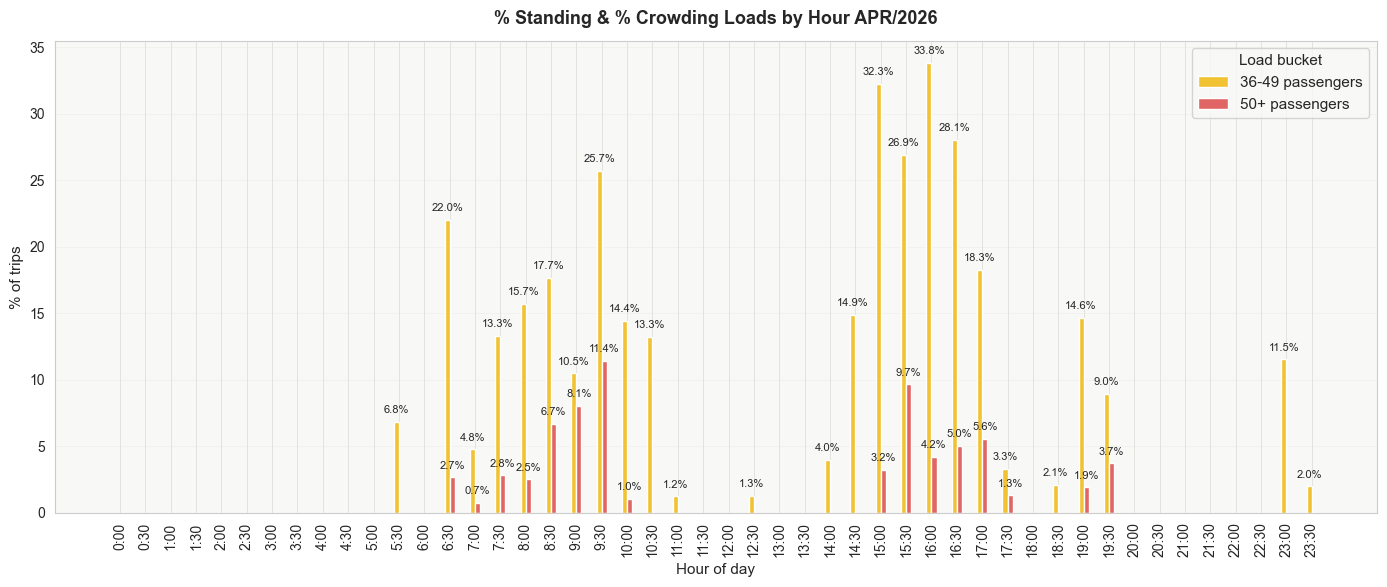

In [32]:

# plot the percent standing/crowding buckets by hour
show_labels = ['36-49', '50+']
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(capacity_pivot_percent.index))
bar_width = 0.2
for idx, bucket in enumerate(show_labels):
    offsets = x + (idx - 0.5) * bar_width
    bars = ax.bar(
        offsets,
        capacity_pivot_percent[bucket].values,
        width=bar_width,
        label=f'{bucket} passengers',
        color=bucket_colors[bucket]
    )

    # show value on each bar, but hide zeros
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.5,
                f'{height:.1f}%',
                ha='center',
                va='bottom',
                fontsize=8
            )

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{int(h)}:{'30' if np.isclose(h % 1, 0.5) else '00'}" for h in capacity_pivot_percent.index],
    rotation=90
)
ax.set_xlabel('Hour of day')
ax.set_ylabel('% of trips')
ax.set_title(f'% Standing & % Crowding Loads by Hour {MONTH}/{YEAR}', pad=12)
ax.legend(title='Load bucket')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


---

## Correlation Capacity vs Headway

Ridership by time of day to the headway

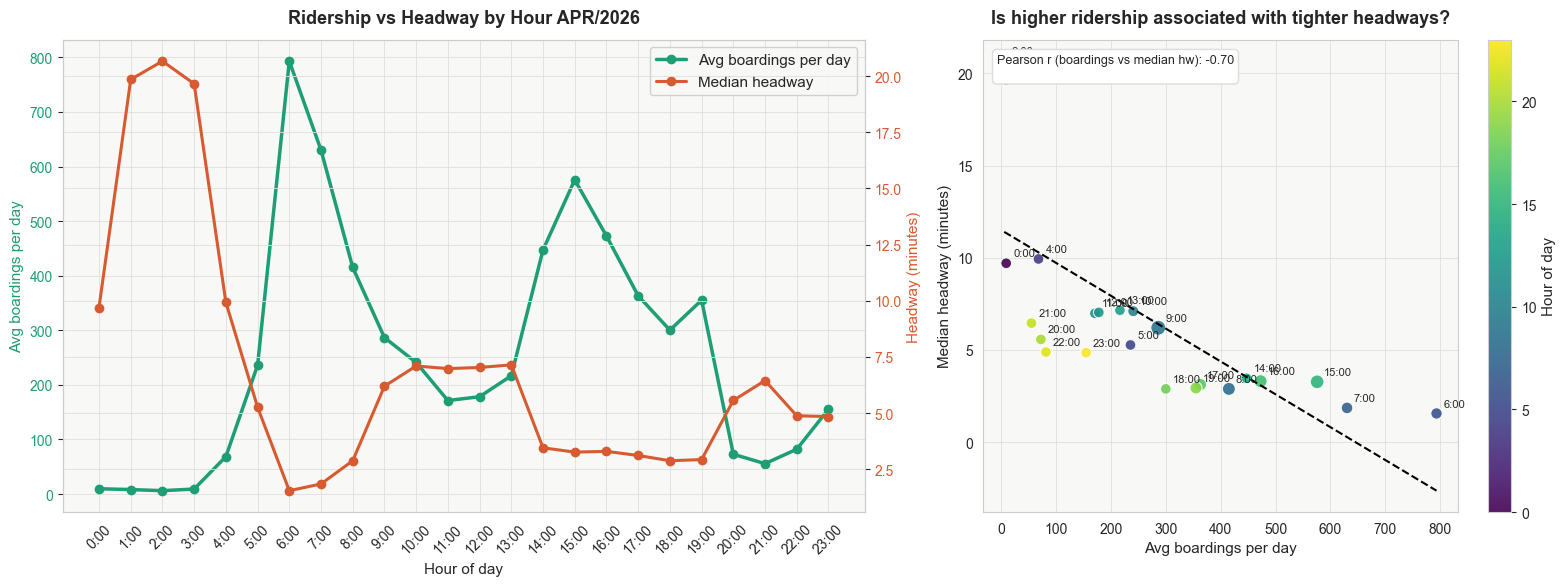

,hour,avg_boardings_per_day,median_headway,p90_headway,avg_pair_load,pct_comfort_plus,pct_crush_load
0,0,9.68,9.70,19.81,1.90,0.00,0.0
1,1,8.18,19.85,21.02,2.59,0.00,0.0
2,2,6.14,20.67,22.82,1.59,0.00,0.0
3,3,9.18,19.66,21.24,1.67,0.00,0.0
4,4,68.50,9.93,11.75,8.25,0.00,0.0
5,5,235.95,5.27,7.90,16.55,0.00,0.0
6,6,793.09,1.55,3.30,18.98,1.28,0.0
7,7,630.23,1.85,4.88,19.10,1.73,0.0
8,8,415.14,2.88,7.22,23.58,4.64,0.0
9,9,286.55,6.20,11.58,27.98,9.28,0.0


Peak average ridership occurs at 6:00 with 793.1 boardings per day.
The highest median headway occurs at 2:00 at 20.7 minutes.
Hourly ridership and median headway correlation: -0.70. A more negative value means tighter headways tend to align with higher demand.


In [33]:
service_days = mc_df['date'].dt.date.nunique()

ridership_vs_headway = (
    hourly_mc_df[['hour', 'total_boardings', 'total_alightings']]
    .merge(
        headway_by_hour[['hour', 'median_headway', 'p75_headway', 'p90_headway']],
        on='hour',
        how='inner'
    )
    .sort_values('hour')
    .copy()
)

ridership_vs_headway['avg_boardings_per_day'] = (
    ridership_vs_headway['total_boardings'] / service_days
)
ridership_vs_headway['avg_alightings_per_day'] = (
    ridership_vs_headway['total_alightings'] / service_days
)

capacity_hourly_summary = (
    capacity_counts
    .assign(
        hour=lambda frame: frame['time_bin'].astype(int),
        comfort_plus=lambda frame: frame['uh_doan_pair_max_load'] >= BUS_CAPACITY_COMFORT,
        crush_load=lambda frame: frame['uh_doan_pair_max_load'] >= BUS_CAPACITY
    )
    .groupby('hour', as_index=False)
    .agg(
        avg_pair_load=('uh_doan_pair_max_load', 'mean'),
        paired_trips=('uh_doan_pair_max_load', 'size'),
        pct_comfort_plus=('comfort_plus', lambda values: values.mean() * 100),
        pct_crush_load=('crush_load', lambda values: values.mean() * 100)
    )
)

ridership_vs_headway = (
    ridership_vs_headway
    .merge(capacity_hourly_summary, on='hour', how='left')
    .sort_values('hour')
    .reset_index(drop=True)
)

corr_median = ridership_vs_headway['avg_boardings_per_day'].corr(
    ridership_vs_headway['median_headway']
)

trend = np.polyfit(
    ridership_vs_headway['avg_boardings_per_day'],
    ridership_vs_headway['median_headway'],
    1
)
trend_x = np.linspace(
    ridership_vs_headway['avg_boardings_per_day'].min(),
    ridership_vs_headway['avg_boardings_per_day'].max(),
    100
)
trend_y = np.polyval(trend, trend_x)

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(16, 6),
    gridspec_kw={'width_ratios': [1.35, 1]}
)

ax1.plot(
    ridership_vs_headway['hour'],
    ridership_vs_headway['avg_boardings_per_day'],
    color=TEAL,
    marker='o',
    linewidth=2.5,
    label='Avg boardings per day'
)
ax1.set_xlabel('Hour of day')
ax1.set_ylabel('Avg boardings per day', color=TEAL)
ax1.tick_params(axis='y', labelcolor=TEAL)
ax1.set_xticks(ridership_vs_headway['hour'])
ax1.set_xticklabels([f"{hour}:00" for hour in ridership_vs_headway['hour']], rotation=45)
ax1.set_title(f'Ridership vs Headway by Hour {MONTH}/{YEAR}', pad=12)

ax1b = ax1.twinx()
ax1b.plot(
    ridership_vs_headway['hour'],
    ridership_vs_headway['median_headway'],
    color=CORAL,
    marker='o',
    linewidth=2.2,
    label='Median headway'
)
ax1b.set_ylabel('Headway (minutes)', color=CORAL)
ax1b.tick_params(axis='y', labelcolor=CORAL)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', framealpha=0.9)

scatter_sizes = ridership_vs_headway['pct_comfort_plus'].fillna(0).mul(6).add(60)
scatter = ax2.scatter(
    ridership_vs_headway['avg_boardings_per_day'],
    ridership_vs_headway['median_headway'],
    s=scatter_sizes,
    c=ridership_vs_headway['hour'],
    cmap='viridis',
    edgecolor='white',
    linewidth=0.8,
    alpha=0.9
)
ax2.plot(trend_x, trend_y, color='black', linestyle='--', linewidth=1.5)

for row in ridership_vs_headway.itertuples(index=False):
    ax2.annotate(
        f"{int(row.hour)}:00",
        (row.avg_boardings_per_day, row.median_headway),
        textcoords='offset points',
        xytext=(5, 5),
        fontsize=8
    )

ax2.set_xlabel('Avg boardings per day')
ax2.set_ylabel('Median headway (minutes)')
ax2.set_title('Is higher ridership associated with tighter headways?', pad=12)
ax2.text(
    0.03,
    0.97,
    f"Pearson r (boardings vs median hw): {corr_median:.2f}\n",
    transform=ax2.transAxes,
    ha='left',
    va='top',
    fontsize=9,
    bbox={'facecolor': 'white', 'edgecolor': '#DDDDDD', 'boxstyle': 'round,pad=0.35'}
)

cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Hour of day')

plt.tight_layout()
plt.show()

display(
    ridership_vs_headway[[
        'hour',
        'avg_boardings_per_day',
        'median_headway',
        'p90_headway',
        'avg_pair_load',
        'pct_comfort_plus',
        'pct_crush_load'
    ]].round(2)
)

peak_demand_hour = ridership_vs_headway.loc[
    ridership_vs_headway['avg_boardings_per_day'].idxmax()
]
worst_headway_hour = ridership_vs_headway.loc[
    ridership_vs_headway['median_headway'].idxmax()
]

print(
    f"Peak average ridership occurs at {int(peak_demand_hour['hour'])}:00 "
    f"with {peak_demand_hour['avg_boardings_per_day']:.1f} boardings per day."
)
print(
    f"The highest median headway occurs at {int(worst_headway_hour['hour'])}:00 "
    f"at {worst_headway_hour['median_headway']:.1f} minutes."
)
print(
    f"Hourly ridership and median headway correlation: {corr_median:.2f}. "
    "A more negative value means tighter headways tend to align with higher demand."
)

A strong negative linear relationship exists between the median headway per time of day and average boardings per time of day. This means that as the median headway decreases, the average boardings at that time increase. This is not necessarily predictive, but instead rather indicates that operationally the headway is decreasing as ridership ramps up and vise versa.


---

## Ridership Trends

Ridership number by day/week or average daily monthly number
Day of week trends?

In [34]:
# total boardings, total active days, average daily boardings in month/year
total_boardings = int(mc_df['boardings'].sum())

total_service_days = mc_df["date"].dt.date.nunique()

average_daily_boardings = total_boardings / total_service_days

print(f"Total boardings in {MONTH}/{YEAR}: {total_boardings}")
print(f"Total active service days in {MONTH}/{YEAR}: {total_service_days}")
print(f"Average daily boardings in {MONTH}/{YEAR}: {average_daily_boardings:.0f}")


Total boardings in APR/2026: 135308
Total active service days in APR/2026: 22
Average daily boardings in APR/2026: 6150


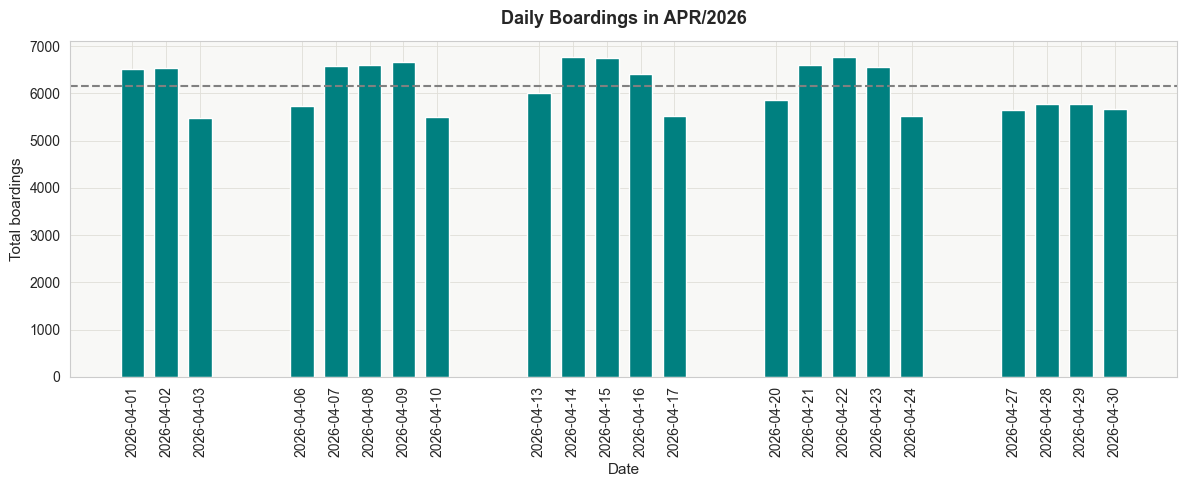

In [35]:
# plot the daily boardings for each day in the month to see variation in day to day
daily_boardings = (
    mc_df.groupby('date')['boardings']
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(daily_boardings['date'], daily_boardings['boardings'], color='teal', width=0.7)
ax.set_xlabel('Date')
ax.set_ylabel('Total boardings')
ax.set_title(f'Daily Boardings in {MONTH}/{YEAR}', pad=12)
ax.xaxis.set_major_locator(plt.MaxNLocator(nbins=10))

ax.axhline(average_daily_boardings, linestyle='--', linewidth=1.5, color='grey', label='Average Daily Boardings')

ax.set_xticks(daily_boardings['date'])
ax.set_xticklabels(daily_boardings['date'].dt.strftime('%Y-%m-%d'))
plt.xticks(rotation=90)
plt.tight_layout()
# plt.savefig(f'1_daily_boardings_{MONTH}_{YEAR}.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
daily_boardings

,date,boardings
0,2026-04-01,6511
1,2026-04-02,6538
2,2026-04-03,5489
3,2026-04-06,5738
4,2026-04-07,6571
5,2026-04-08,6611
6,2026-04-09,6669
7,2026-04-10,5496
8,2026-04-13,6013
9,2026-04-14,6763


Spring break is visible on the plot here. It is clear that ridership is lower on Mondays and Fridays in March 2026.


---

### **Are Dwell Times from 10pm - 12am Longer on Average?**

In [37]:
# find the median dwell time by hour
mc_df_ob = mc_df[mc_df['direction'] == 'Inbound'].copy()

dwell_by_hour = (
    mc_df_ob.groupby('hour')['dwell_sec']
    .median()
    .reset_index()
)

dwell_by_hour

,hour,dwell_sec
0,0,35.0
1,1,41.0
2,2,35.0
3,3,40.0
4,4,40.0
5,5,81.5
6,6,90.0
7,7,46.0
8,8,46.0
9,9,49.0


Text(0.5, 0, 'Hour of day')

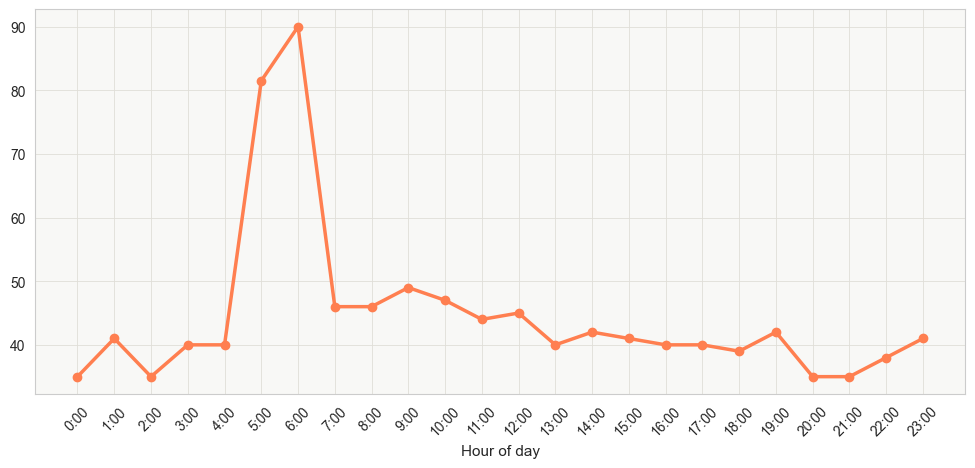

In [38]:
# plot the median dwell time by hour to see how it fluctuates across the day
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(dwell_by_hour['hour'], dwell_by_hour['dwell_sec'], marker='o', color='coral', linewidth=2.5)
ax.set_xticks(dwell_by_hour['hour'])
ax.set_xticklabels([f'{h}:00' for h in dwell_by_hour['hour']], rotation=45)
ax.set_xlabel('Hour of day')


---

## Visualization 8: Final Recommendations

Current Headway Targets (4/21/2026):
| **Time Period** | **Target Headway** (minutes) | Notes:                       |
|-----------------|------------------------------|------------------------------|
| 0000 - 0500     | 20                           | 1 bus running                |
| 0500 - 0600     | 10                           |                              |
| 0600 - 0800     | 3                            | Current peak morning hours   |
| 0800 - 1400     | 10                           |                              |
| 1400 - 2000     | 5                            | Current peak afternoon hours |
| 2000 - 2200     | 10                           |                              |
| 2200 - 0000     | 5                            | "Second" afternoon peak      |


### Recommendations:

Given the data I have analyzed, 